# 데이터분석

## 분석 범위
- 최성영: 전환 고객 기준 오퍼 전/후 거래 비교
- 조준익: 가입기간 / 오퍼 횟수 기반 전환 분석
- 김지륜: 채널 분석
- 이승복: 오퍼 속성 / 통계 검정
- 이주성: 세그먼트 / 프로모션 유형 / 세부 오퍼 비교
- 공용 분석: 전체 퍼널 분포와 단계별 전환율

## 해석 기준
1. `informational` 오퍼는 구조상 `completed` 해석이 어렵다.\
따라서 `viewed → completed` 비교는 `bogo`, `discount` 중심으로 해석한다.

2. `Missing` 그룹은 고객 정보가 없는 행이 섞여 있으므로\
성별, 연령, 소득, 가입 코호트의 실질적인 고객 특성으로 해석하지 않는다.

3. p-value가 매우 작더라도 표본 수가 크면 작은 차이도 유의하게 나올 수 있다.\
따라서 통계 검정은 효과크기와 실제 전환율 차이를 함께 보고 해석한다.

4. 일부 비교는 기술통계 기반 요약이다.\
특히 오퍼 전/후 거래 비교는 전환 고객만을 대상으로 하므로,\
인과관계라기보다 행동 변화의 보조 신호로 해석한다.

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform

import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 공통 점검 함수

In [2]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

# 데이터 로드 및 원본 구조 확인

In [3]:
# 데이터 로드
df = pd.read_csv("data/funnel_final.csv")

# 원본 훼손 방지를 위해 복제본 사용
funnel = df.copy()
check_basic_info(funnel, 'funnel_final')


funnel_final의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,38
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
days_as_member,float64,66501,87.18,9776,12.82,1707
member_year,float64,66501,87.18,9776,12.82,6
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22


[테이블 요약]


,customer_id,offer_id,time_received,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final,status,channel_count,channel_combo,has_profile,gender_group,age_group,income_group,member_year,member_cohort,days_as_member,days_as_member_group,offer_count
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,discount,2.0,10.0,7.0,1,1,1,0,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1,converted,3,web+email+mobile,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336,informational,0.0,0.0,4.0,1,1,1,0,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0,viewed_not_converted,3,web+email+mobile,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168,informational,0.0,0.0,3.0,0,1,1,1,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0,viewed_not_converted,3,email+mobile+social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408,bogo,5.0,5.0,5.0,1,1,1,1,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1,converted,4,web+email+mobile+social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504,discount,2.0,10.0,10.0,1,1,1,1,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1,converted,4,web+email+mobile+social,1,M,40대,6~8만,2017.0,2017-2018,467.0,~500일,5


# 공통 전처리 / 분석용 파생 컬럼

In [4]:
# ============================================================
# 공통 전처리
# completed 해석이 어려운 informational 제외용 데이터 분리
# 조원 코드에서 공통으로 쓰는 converted_final 컬럼 정리
# 공용 색상 지정
# ============================================================
# 순서형 그래프용 색상
base_colors = ['#D4E9E2', '#4AA87A', '#00704A', '#CBA258']


# completed 분석용: informational 제외
funnel_offer = funnel[funnel['offer_type'] != 'informational'].copy()

print("공통 파생 컬럼 생성 완료")
display(
    funnel[
        [
            'web',              # 웹 채널 오퍼 전달 여부
            'email',            # 이메일 채널 오퍼 전달 여부
            'mobile',           # 모바일 채널 오퍼 전달 여부
            'social',           # 소셜 채널 오퍼 전달 여부
            'channel_count',    # 오퍼 발송 채널 수
            'channel_combo',    # 오퍼 발송 채널 조합
            'converted_final'   # 최종 전환 여부
        ]
    ]
    .drop_duplicates()
    .sort_values(['channel_count', 'channel_combo'])
    .head(3)
)

공통 파생 컬럼 생성 완료


,web,email,mobile,social,channel_count,channel_combo,converted_final
7,1,1,0,0,2,web+email,1
26,1,1,0,0,2,web+email,0
2,0,1,1,1,3,email+mobile+social,0


# 최성영의 분석

1. 전환 오퍼 전/후 거래 횟수 · 거래 금액 비교  
   - 기준: `segment == converted` 고객  
   - 목적: 전환 고객의 오퍼 전/후 거래 활동 변화를 보조 지표로 확인

In [5]:
# customer_compare_final 로드
# 고객 단위 전/후 거래 비교 테이블
customer_compare = pd.read_csv("data/customer_compare_final.csv")

print("=" * 80)
print("customer_compare_final 로드")
print("=" * 80)
print("shape:", customer_compare.shape)
display(customer_compare.head())

print("\n[segment 분포]")
display(
    customer_compare['segment']
    .value_counts(dropna=False)
    .rename_axis('segment')
    .reset_index(name='customer_cnt')
)

customer_compare_final 로드
shape: (16994, 6)


,customer_id,segment,before_count,before_amount,after_count,after_amount
0,0009655768c64bdeb2e877511632db8f,converted,4,44.81,12,166.01
1,00116118485d4dfda04fdbaba9a87b5c,not_converted,0,0.00,0,0.00
2,0011e0d4e6b944f998e987f904e8c1e5,converted,2,25.42,5,88.02
3,0020c2b971eb4e9188eac86d93036a77,converted,0,0.00,6,149.43
4,0020ccbbb6d84e358d3414a3ff76cffd,converted,10,136.26,11,137.78



[segment 분포]


,segment,customer_cnt
0,converted,12774
1,not_converted,4220


In [6]:
# 해석 주의: 이 비교는 전환 고객만 대상으로 한 기술통계 비교이며, 인과효과를 직접 증명하는 분석은 아님
# ============================================================
# 전환 고객 기준 오퍼 전/후 거래 비교표 생성
# not_converted 고객은 비교 기준 시점이 없어 전/후 값이 0으로 채워질 수 있음
# 따라서 메인 비교는 converted 고객만 대상으로 사용
# ============================================================

# 전환 고객만 추출
converted_compare = customer_compare[
    customer_compare['segment'] == 'converted'
].copy()

# 오퍼 전/후 평균 / 중앙값 비교 요약표 생성
offer_effect_summary = pd.DataFrame({
    '지표': ['거래 횟수', '거래 금액'],
    '오퍼 전 평균': [
        converted_compare['before_count'].mean(),
        converted_compare['before_amount'].mean()
    ],
    '오퍼 후 평균': [
        converted_compare['after_count'].mean(),
        converted_compare['after_amount'].mean()
    ],
    '오퍼 전 중앙값': [
        converted_compare['before_count'].median(),
        converted_compare['before_amount'].median()
    ],
    '오퍼 후 중앙값': [
        converted_compare['after_count'].median(),
        converted_compare['after_amount'].median()
    ]
})

# 오퍼 전후 평균 증감 계산
offer_effect_summary['평균 증감'] = (
    offer_effect_summary['오퍼 후 평균'] - offer_effect_summary['오퍼 전 평균']
)

# 오퍼 전 평균 대비 평균 증감률 계산
# 오퍼 전 평균이 0이면 나눗셈이 불가능하므로 NaN 처리
offer_effect_summary['평균 증감률(%)'] = np.where(
    offer_effect_summary['오퍼 전 평균'] != 0,
    offer_effect_summary['평균 증감'] / offer_effect_summary['오퍼 전 평균'] * 100,
    np.nan
)

# 표 숫자 자리수 정리
offer_effect_summary = offer_effect_summary.round(2)

# 오퍼 전후 거래 컬럼의 세부 통계 요약표 생성
# 평균, 중앙값, 표준편차, 최소값, 최대값을 함께 확인
offer_effect_detail = (
    converted_compare[['before_count', 'after_count', 'before_amount', 'after_amount']]
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={'index': '컬럼'})
    .round(2)
)

# 결과 출력
print("=" * 80)
print("최성영 분석: 전환 고객 기준 오퍼 전/후 거래 비교")
print("=" * 80)
print("분석 대상 고객 수:", converted_compare['customer_id'].nunique())
display(offer_effect_summary)

print("\n[세부 요약]")
display(offer_effect_detail)

최성영 분석: 전환 고객 기준 오퍼 전/후 거래 비교
분석 대상 고객 수: 12774


,지표,오퍼 전 평균,오퍼 후 평균,오퍼 전 중앙값,오퍼 후 중앙값,평균 증감,평균 증감률(%)
0,거래 횟수,4.64,7.91,3.00,6.00,3.27,70.39
1,거래 금액,75.18,130.89,38.09,86.35,55.71,74.10



[세부 요약]


,컬럼,mean,median,std,min,max
0,before_count,4.64,3.00,4.62,0.0,36.00
1,after_count,7.91,6.00,5.83,0.0,43.00
2,before_amount,75.18,38.09,118.06,0.0,2142.57
3,after_amount,130.89,86.35,166.33,0.0,2534.69


## 해석
전환 고객만 따로 보면 오퍼 후 거래 활동은 전반적으로 증가한 모습이다.

- 거래 횟수 평균: 4.64회 → 7.91회, 약 70.39% 증가
- 거래 금액 평균: 75.18달러 → 130.89달러, 약 74.10% 증가
- 중앙값도 함께 상승해, 일부 극단값만의 변화가 아니라 전체 분포가 위로 이동한 것으로 볼 수 있다.

다만 해당 결과는 `segment == converted` 고객만 대상으로 본 전후 비교로,\
"오퍼 때문에 거래가 증가했다"는 인과 증거로 단정할 순 없다.\
더 정확하게는 전환 고객이 원래도 더 활발했거나, 오퍼 이후 구매 활동이 이어지는지 보조적 근거로 활용하는것이 적절하다.

---

# 조준익의 분석
1. 고객 가입기간별 전환율  
2. 고객 가입기간 × 오퍼 횟수 히트맵  

- 기준 데이터: `funnel_offer` (`informational` 제외)
- 오퍼 횟수는 고객별 수신 오퍼 건수 사용
- 오퍼 횟수는 값 범위가 크지 않아 구간화하지 않고 원값 기준으로 히트맵 구성

In [7]:
# 가입기간 / 오퍼 횟수 분석용 기준 데이터 생성

# 조준익의 분석을 위한 데이터 복사
junik_base = funnel_offer.copy()

# 순서 정렬
tenure_order = ['~200일', '~500일', '~1000일', '1000일+', 'Missing']
offer_count_order = sorted(junik_base['offer_count'].dropna().astype(int).unique().tolist())

junik_base['days_as_member_group'] = pd.Categorical(
    junik_base['days_as_member_group'],
    categories=tenure_order,
    ordered=True
)

# 오퍼 수신 횟수 자료형 정리
# 결측치를 유지할 수 있는 정수형(Int64)으로 변환
junik_base['offer_count'] = junik_base['offer_count'].astype('Int64')

# 생성 결과 확인
print("=" * 80)
print("조준익 분석용 데이터 확인")
print("=" * 80)
print("shape:", junik_base.shape)
display(
    junik_base[
        [
            'customer_id',            # 고객 ID
            'offer_id',               # 오퍼 ID
            'offer_type',             # 오퍼 유형
            'days_as_member',         # 가입 후 경과일
            'days_as_member_group',   # 가입 경과일 구간
            'offer_count',            # 고객별 오퍼 수신 횟수
            'converted_final'         # 최종 전환 여부
        ]
    ].head()
)


조준익 분석용 데이터 확인
shape: (61042, 38)


,customer_id,offer_id,offer_type,days_as_member,days_as_member_group,offer_count,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,467.0,~500일,5,1
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,467.0,~500일,5,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,467.0,~500일,5,1
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,NaN,Missing,2,0
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,NaN,Missing,2,0


고객 가입기간별 전환율 (행 단위, Missing 제외)


,days_as_member_group,received_cnt,converted_cnt,conversion_rate
0,0 ~ 200일,12208,4591,37.606488
1,200 ~ 500일,18879,10709,56.724403
2,500 ~ 1000일,14586,11896,81.557658
3,1000일 +,7528,4851,64.439426


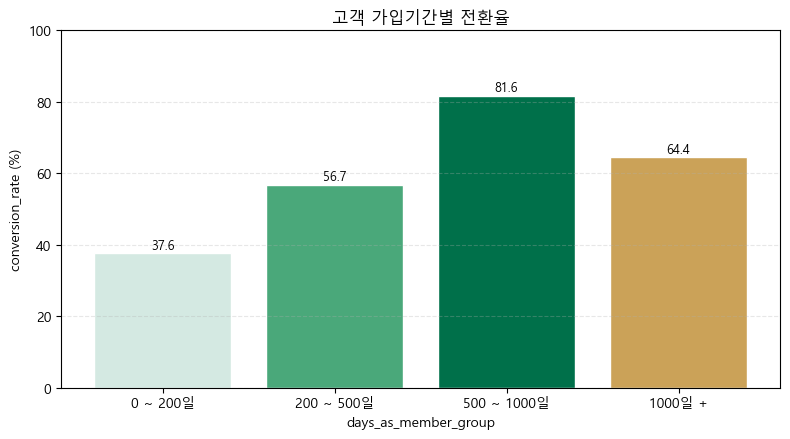

In [8]:
# 해석 포인트: 가입기간이 길수록 항상 좋아지는지보다, 어느 구간에서 반응이 가장 높은지 확인하는 데 목적이 있음
# ============================================================
# 고객 가입기간별 전환율
# converted_final = 1 인 행 개수 / 전체 행 개수
# Missing 구간은 제외하고 확인
# ============================================================

# Missing 구간은 제외
plot_df = junik_base[
    junik_base['days_as_member_group'].notna() &
    (junik_base['days_as_member_group'] != 'Missing')
].copy()

# 가입기간 구간별 집계
tenure_conversion = (
    plot_df
    .groupby('days_as_member_group', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),      # 가입기간 구간별 전체 오퍼 수신 건수
        converted_cnt=('converted_final', 'sum')   # 가입기간 구간별 전환된 오퍼 건수
    )
    .reset_index()
)

# 전환율 계산
# 전환된 오퍼 건수 / 전체 오퍼 수신 건수 * 100
tenure_conversion['conversion_rate'] = (
    tenure_conversion['converted_cnt'] / tenure_conversion['received_cnt'] * 100
)

# Categorical -> 문자열로 변환 후 라벨 변경
tenure_conversion['days_as_member_group'] = (
    tenure_conversion['days_as_member_group'].astype(str)
)

# x축에 표시할 라벨로 변경
label_map = {
    '~200일': '0 ~ 200일',
    '~500일': '200 ~ 500일',
    '~1000일': '500 ~ 1000일',
    '1000일+': '1000일 +'
}

# 기존 컬럼이 categorical일 수 있으므로 문자열로 변환 후 라벨 변경
tenure_conversion['days_as_member_group'] = (
    tenure_conversion['days_as_member_group']
    .astype(str)
    .replace(label_map)
)

# 라벨 순서 지정
tenure_order = ['0 ~ 200일', '200 ~ 500일', '500 ~ 1000일', '1000일 +']

# pd.Categorical로 순서를 고정한 뒤 정렬
tenure_conversion['days_as_member_group'] = pd.Categorical(
    tenure_conversion['days_as_member_group'],
    categories=tenure_order,
    ordered=True
)

# 지정한 범주 순서 기준으로 정렬
tenure_conversion = tenure_conversion.sort_values('days_as_member_group')


# 집계 결과 출력
print("=" * 80)
print("고객 가입기간별 전환율 (행 단위, Missing 제외)")
print("=" * 80)
display(tenure_conversion)

# 막대그래프 생성
plt.figure(figsize=(8, 4.5))
bars = plt.bar(
    tenure_conversion['days_as_member_group'].astype(str),
    tenure_conversion['conversion_rate'],
    color=base_colors[:len(tenure_conversion)],
    edgecolor='white'
)

# 그래프 제목 및 축 라벨 설정
plt.title('고객 가입기간별 전환율')
plt.xlabel('days_as_member_group')
plt.ylabel('conversion_rate (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 막대 위에 전환율 값 표시
for bar, v in zip(bars, tenure_conversion['conversion_rate']):
    if pd.notna(v):
        plt.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            v + 0.5,                             # y좌표: 막대 높이보다 조금 위에 표시
            f'{v:.1f}',                          # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

plt.tight_layout()
plt.show()

## 해석
가입기간별 전환율은 단순한 직선 구조가 아니라, 특정 구간에서 가장 높아지는 형태로 나타났다.
- `0 ~ 200일`: 37.61%
- `200 ~ 500일`: 56.72%
- `500 ~ 1000일`: 81.56%
- `1000일 +`: 64.44%

즉, 가입 초기 고객은 전환율이 낮고, 어느 정도 멤버십이 숙성된 고객군에서 전환이 가장 높았다.

반대로 가장 오래된 고객군이 항상 최고 전환율을 보인 것은 아니므로,\
"가입기간이 길수록 무조건 전환이 높다"기보다 "중간 이상으로 숙성된 고객군이 가장 잘 반응한다"는 해석이 더 적절하다 할수있다.

고객 가입기간 × 오퍼 횟수 전환율 히트맵용 표


offer_count,1,2,3,4,5,6
days_as_member_group_label,,,,,,
0 ~ 200일,35.714286,39.325843,39.180172,36.961174,37.857727,37.232525
200 ~ 500일,66.666667,53.979239,56.748995,56.080942,57.806191,55.777242
500 ~ 1000일,87.500000,78.838174,79.479769,80.528053,82.341341,82.467911
1000일 +,57.142857,68.181818,62.320917,63.141840,66.197679,63.689527


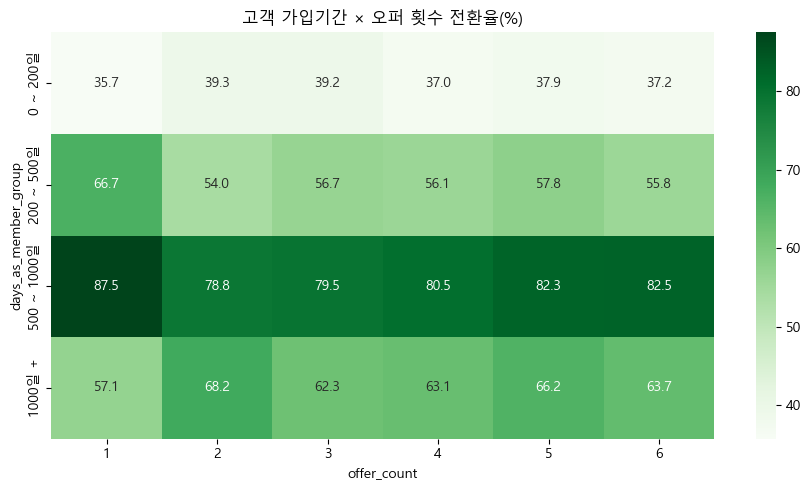

In [9]:
# ============================================================
# 고객 가입기간 × 오퍼 횟수 전환율 히트맵 생성
# - Missing 구간 제외
# - 오퍼 횟수는 별도 구간화 없이 원값 기준 사용
# - 가입기간 구간 라벨을 보기 좋게 바꾼 뒤 히트맵으로 시각화
# ============================================================

# Missing 제외용 데이터 복사
# 가입기간 정보가 없는 행과 'Missing'으로 분류된 행은 제외
plot_df = junik_base[
    junik_base['days_as_member_group'].notna() &
    (junik_base['days_as_member_group'] != 'Missing')
].copy()

# x축에 표시할 라벨로 변경
label_map = {
    '~200일': '0 ~ 200일',
    '~500일': '200 ~ 500일',
    '~1000일': '500 ~ 1000일',
    '1000일+': '1000일 +'
}

# 기존 컬럼이 categorical일 수 있으므로 문자열로 변환 후 라벨 변경
plot_df['days_as_member_group_label'] = (
    plot_df['days_as_member_group']
    .astype(str)
    .replace(label_map)
)

# 라벨 순서 지정
tenure_order = ['0 ~ 200일', '200 ~ 500일', '500 ~ 1000일', '1000일 +']

plot_df['days_as_member_group_label'] = pd.Categorical(
    plot_df['days_as_member_group_label'],
    categories=tenure_order,
    ordered=True
)

# 히트맵용 피벗 테이블 생성
# 가입기간 구간 × 오퍼 횟수 조합별 converted_final 평균을 계산
tenure_offer_heatmap = (
    plot_df
    .groupby(['days_as_member_group_label', 'offer_count'], dropna=False)['converted_final']
    .mean()        # 조합별 전환율 계산
    .mul(100)      # 퍼센트(%) 단위로 변환
    .unstack()     # 히트맵 형태로 보기 위해 열 방향으로 펼침
)

# 행/열 순서 정리
# 행은 가입기간 구간 순서, 열은 오퍼 수신 횟수 순서로 고정
tenure_offer_heatmap = tenure_offer_heatmap.reindex(index=tenure_order)
tenure_offer_heatmap = tenure_offer_heatmap.reindex(columns=offer_count_order)

# 히트맵용 집계표 출력
print("=" * 80)
print("고객 가입기간 × 오퍼 횟수 전환율 히트맵용 표")
print("=" * 80)
display(tenure_offer_heatmap)

# ============================================================
# 히트맵 시각화
# 행: 가입기간 구간 / 열: 오퍼 수신 횟수 / 값: 전환율(%)
# ============================================================
plt.figure(figsize=(9, 5))
sns.heatmap(
    tenure_offer_heatmap,
    annot=True,    # 셀 안에 전환율 수치 표시
    fmt='.1f',     # 소수점 첫째 자리까지 표시
    cmap='Greens'  # 색상 팔레트
)

# 그래프 제목 및 축 라벨 설정
plt.title('고객 가입기간 × 오퍼 횟수 전환율(%)')
plt.xlabel('offer_count')
plt.ylabel('days_as_member_group')

# 레이아웃 정리 후 그래프 출력
plt.tight_layout()
plt.show()

## 해석
가입기간과 오퍼 수신 횟수를 함께 보면, 전환율은 주로 가입기간 구간에 따라 더 크게 갈린다.

- `500 ~ 1000일` 구간은 오퍼 횟수 1~6회 전반에서 약 78~87%로 가장 높다.
- `0 ~ 200일` 구간은 오퍼 횟수와 관계없이 전반적으로 30%대 후반에 머문다.
- `1000일 +` 구간은 `500 ~ 1000일`보다는 낮지만, 초기 고객보다는 높다.

즉, 오퍼를 몇 번 받았는가도 중요하지만, 그보다 먼저 고객의 멤버십 숙성도가 전환에 더 큰 영향을 주는 패턴이 보인다.\
다만 일부 칸은 표본 수가 작을 수 있으므로, 극단값 하나만 떼어 해석하기보다 전체 흐름 중심으로 보는 것이 안전하다.

# 김지륜의 분석

채널 관련 분석
- 기준 데이터는 `informational`을 제외한 `funnel_offer`

In [10]:
print("=" * 80)
print("검증단계")
print("=" * 80)

print("received 기준 전체 건수:", len(funnel_offer))
print("completed가 붙은 건수:", funnel_offer['has_completed_rc'].sum())
print("최종 전환 건수:", funnel_offer['converted_final'].sum())
print()
print("최종 전환율:", round(funnel_offer['converted_final'].mean() * 100, 2), "%")

검증단계
received 기준 전체 건수: 61042
completed가 붙은 건수: 33152
최종 전환 건수: 33152

최종 전환율: 54.31 %


In [11]:
# 해석 주의: 채널 효과는 단일 채널 효과라기보다 채널 조합 특성까지 함께 반영된 결과임

# 채널 분석용 기준 테이블 생성
# 공통 전처리에서 만든 channel_count / channel_combo / converted_final 사용

# ============================================================
# 김지륜
# 채널 분석 전반
# - 기준 데이터: funnel_offer
# - 공통 전처리에서 만든 channel_count / channel_combo / converted_final 사용
# - completed 해석이 가능한 오퍼 기준으로 채널 효과 확인
# ============================================================

channel_base = funnel_offer.copy()

print("=" * 80)
print("김지륜 채널 분석용 데이터")
print("=" * 80)
print("shape:", channel_base.shape)
display(
    channel_base[
        ['customer_id', 'offer_id', 'offer_type', 'channel_count', 'channel_combo', 'converted_final']
    ].head()
)

김지륜 채널 분석용 데이터
shape: (61042, 38)


,customer_id,offer_id,offer_type,channel_count,channel_combo,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,3,web+email+mobile,1
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,4,web+email+mobile+social,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,4,web+email+mobile+social,1
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,4,web+email+mobile+social,0
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,4,web+email+mobile+social,0


In [12]:
# 전환율 집계 함수
def conversion_table(df, group_col, sort_by_rate=False):
    
    # 그룹별 오퍼 수신 건수 / 전환 건수 집계
    result = (
        df.groupby(group_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),         # received_cnt  : 해당 그룹의 전체 행 수
            converted_cnt=('converted_final', 'sum')      # converted_cnt : 해당 그룹에서 converted_final=1 인 행 수
        )
        .reset_index()
    )

    # 전환율 계산: 전환 건수 / 전체 수신 건수 * 100
    result['conversion_rate'] = result['converted_cnt'] / result['received_cnt'] * 100

    # 전환율 기준 내림차순 정렬 옵션
    if sort_by_rate:
        result = result.sort_values('conversion_rate', ascending=False)
    
    # 인덱스 정리 후 반환
    return result.reset_index(drop=True)

In [13]:
# 전환율 막대그래프 함수
def plot_conversion_rate(df, group_col, title, sort_by_rate=False, figsize=(8, 5)):
    
    # 전환율 집계표 생성
    plot_df = conversion_table(df, group_col, sort_by_rate=sort_by_rate).copy()

    # 막대 개수만큼 색상이 부족하지 않도록 base_colors를 반복 확장
    repeat_n = (len(plot_df) // len(base_colors)) + 1
    ordered_colors = (base_colors * repeat_n)[:len(plot_df)]

    # 막대그래프 생성
    plt.figure(figsize=figsize)
    bars = plt.bar(
        plot_df[group_col].astype(str),   # x축: 그룹 컬럼 값
        plot_df['conversion_rate'],       # y축: 전환율(%)
        color=ordered_colors,
        edgecolor='white'
    )

    # 막대 위에 전환율 수치 표시
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            height,                              # y좌표: 막대 높이 위치
            f'{height:.1f}%',                    # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    # 그래프 제목 및 축 라벨 설정
    plt.title(title)
    plt.xlabel(str(group_col))
    plt.ylabel('Conversion Rate (%)')

    # y축 범위 설정
    # 최대값보다 약간 크게 잡아 막대 위 텍스트가 잘 보이도록 설정
    plt.ylim(0, plot_df['conversion_rate'].max() * 1.15 if len(plot_df) > 0 else 1)

    # 보조선 및 레이아웃 정리
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
# ============================================================
# 채널 여부(0/1) 전용 막대그래프 함수
# ============================================================
def plot_conversion_rate2(df, group_col, title, ax):

    # 그룹별 전환율 집계표 생성
    plot_df = conversion_table(df, group_col).copy()

    # 0/1 값에 따라 사용할 색상 정의
    binary_color_map = {
        '0': '#4AA87A',   # 채널 없음
        '1': '#00704A'    # 채널 포함
    }

    # 0/1 값을 그래프용 한글 라벨로 변환
    binary_label_map = {
        '0': '채널 없음',
        '1': '채널 포함'
    }

    # 그룹 컬럼 값을 문자열로 변환
    x_values = plot_df[group_col].astype(str)               # 색상 매핑과 라벨 변환에 사용

    # 각 값(0/1)에 맞는 색상과 x축 라벨 생성
    bar_colors = [binary_color_map[v] for v in x_values]
    x_labels = [binary_label_map[v] for v in x_values]

    # 막대그래프 생성
    bars = ax.bar(
        x_labels,                       # x축: 채널 포함 여부 라벨
        plot_df['conversion_rate'],     # y축: 전환율(%)
        color=bar_colors,
        edgecolor='white'
    )

    # 막대 위에 전환율 값 표시
    for bar, rate in zip(bars, plot_df['conversion_rate']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            bar.get_height(),                    # y좌표: 막대 높이 위치
            f'{rate:.1f}%',                      # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    # 그래프 제목 및 축 라벨 설정
    ax.set_title(title)
    ax.set_xlabel(str(group_col))
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_ylim(0, plot_df['conversion_rate'].max() * 1.15 if len(plot_df) > 0 else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

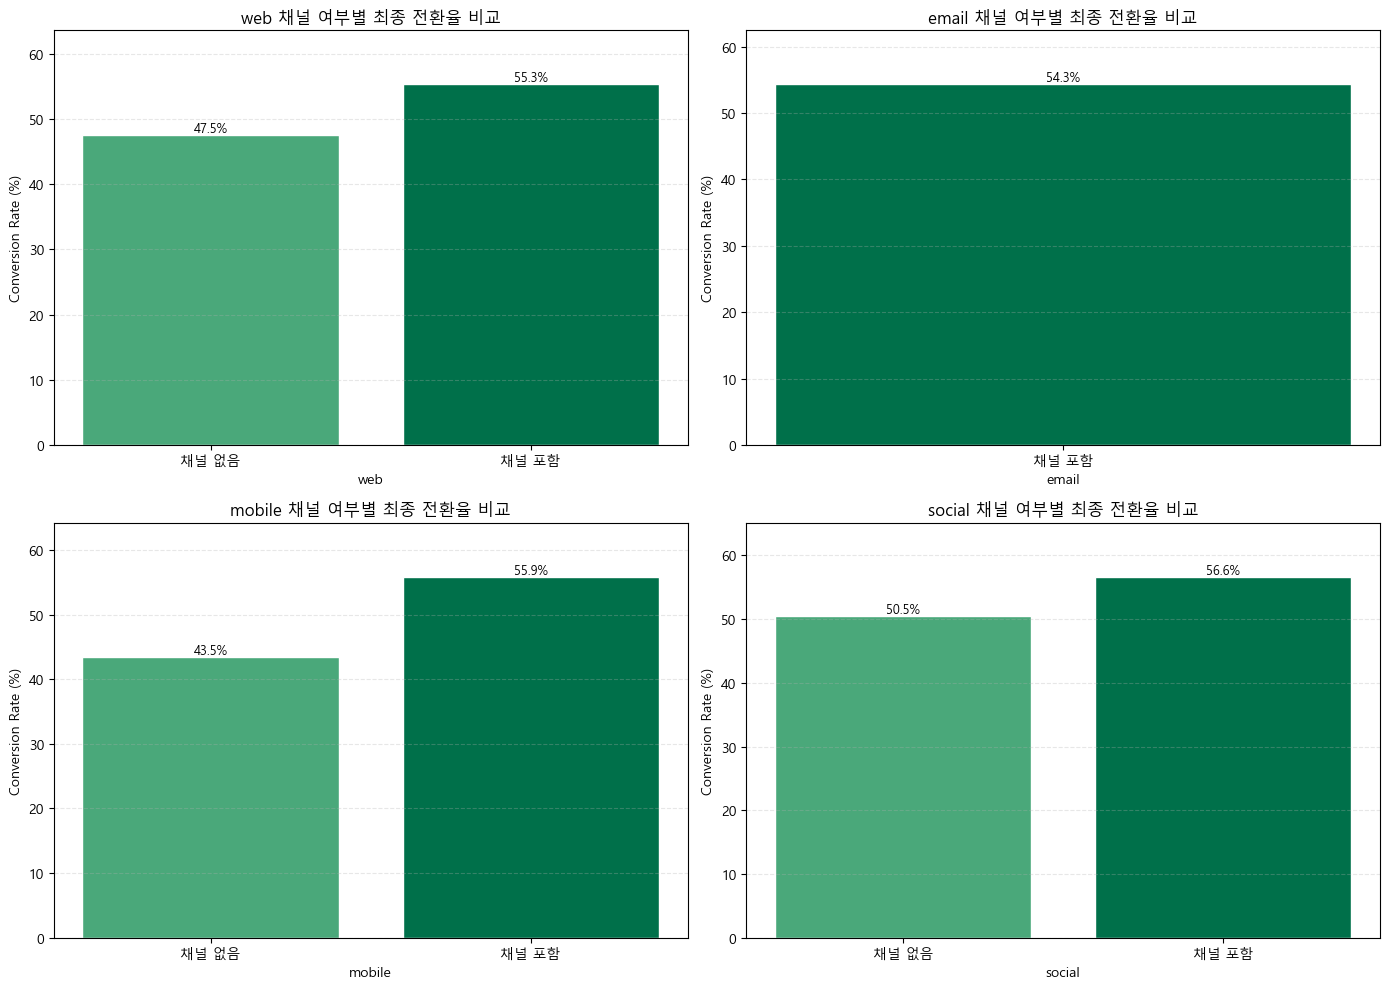

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_conversion_rate2(channel_base, 'web', 'web 채널 여부별 최종 전환율 비교', ax=axes[0, 0])
plot_conversion_rate2(channel_base, 'email', 'email 채널 여부별 최종 전환율 비교', ax=axes[0, 1])
plot_conversion_rate2(channel_base, 'mobile', 'mobile 채널 여부별 최종 전환율 비교', ax=axes[1, 0])
plot_conversion_rate2(channel_base, 'social', 'social 채널 여부별 최종 전환율 비교', ax=axes[1, 1])

plt.tight_layout()
plt.show()

채널 조합별 최종 전환율


,channel_combo,received_cnt,converted_cnt,conversion_rate
0,email+mobile+social,7658,3635,47.466701
1,web+email,7668,3334,43.479395
2,web+email+mobile,15309,8261,53.961722
3,web+email+mobile+social,30407,17922,58.940376


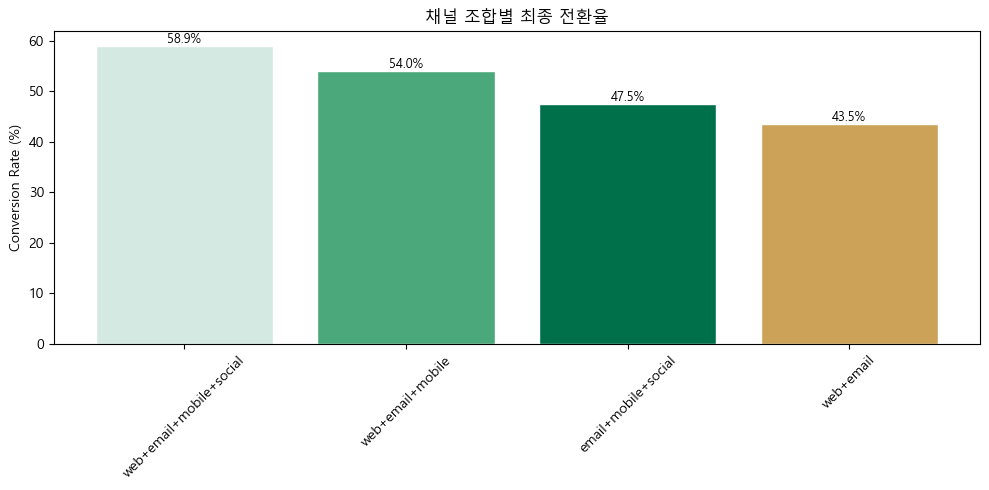

In [16]:
# 채널 조합별 최종 전환율 계산 및 시각화
# channel_combo 기준으로 오퍼 수신 건수 / 전환 건수 / 전환율 집계

# 채널 조합별 최종 전환율 집계
channel_combo_result = conversion_table(channel_base, 'channel_combo')

# 결과 출력
print("=" * 80)
print("채널 조합별 최종 전환율")
print("=" * 80)
display(channel_combo_result)


# 전환율 기준 상위 5개 채널 조합 추출
top_channel = (
    channel_combo_result
    .sort_values('conversion_rate', ascending=False) # 정렬 필요없을 경우 제거
    .head()
)

# 막대그래프 생성
plt.figure(figsize=(10, 5))
bars = plt.bar(
    top_channel['channel_combo'],       # x축: 채널 조합
    top_channel['conversion_rate'],     # y축: 전환율(%)
    color=base_colors[:len(top_channel)],
    edgecolor='white'
)

# 막대 위에 전환율 값 표시
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
        h,                                   # y좌표: 막대 높이 위치
        f'{h:.1f}%',                         # 표시할 텍스트: 소수점 첫째 자리까지 출력
        ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
        va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
        fontsize=9                           # 글자 크기
    )

# x축 라벨 회전
plt.xticks(rotation=45)


plt.title('채널 조합별 최종 전환율')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()

mobile 포함 여부별 최종 전환율


,mobile_flag,received_cnt,converted_cnt,conversion_rate
0,0,7668,3334,43.479395
1,1,53374,29818,55.866152


채널 수별 최종 전환율


,channel_count,received_cnt,converted_cnt,conversion_rate
0,2,7668,3334,43.479395
1,3,22967,11896,51.796055
2,4,30407,17922,58.940376


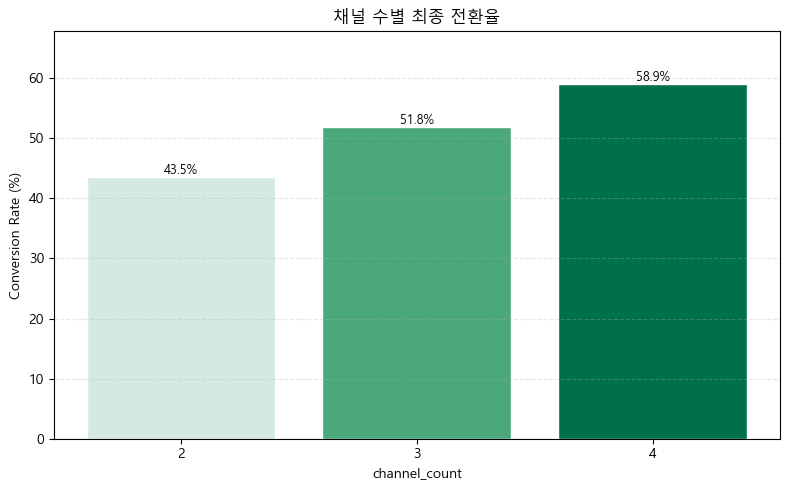

In [17]:
# mobile 포함 여부 / 채널 수별 최종 전환율

channel_base['mobile_flag'] = channel_base['mobile']

print("=" * 80)
print("mobile 포함 여부별 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, 'mobile_flag'))

print("=" * 80)
print("채널 수별 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, 'channel_count'))

plot_conversion_rate(channel_base, 'channel_count', '채널 수별 최종 전환율')

In [18]:
# offer_type × mobile / 채널별 보조 표
# 메인 그래프 외에 세부 분해 확인용 표

print("=" * 80)
print("offer_type × mobile 최종 전환율")
print("=" * 80)
display(conversion_table(channel_base, ['offer_type', 'mobile']))

print("=" * 80)
print("채널별 보조 비교표")
print("=" * 80)
display(conversion_table(channel_base, 'mobile'))
display(conversion_table(channel_base, 'web'))
display(conversion_table(channel_base, 'email'))
display(conversion_table(channel_base, 'social'))

offer_type × mobile 최종 전환율


,offer_type,mobile,received_cnt,converted_cnt,conversion_rate
0,bogo,1,30499,15501,50.824617
1,discount,0,7668,3334,43.479395
2,discount,1,22875,14317,62.587978


채널별 보조 비교표


,mobile,received_cnt,converted_cnt,conversion_rate
0,0,7668,3334,43.479395
1,1,53374,29818,55.866152


,web,received_cnt,converted_cnt,conversion_rate
0,0,7658,3635,47.466701
1,1,53384,29517,55.291848


,email,received_cnt,converted_cnt,conversion_rate
0,1,61042,33152,54.310147


,social,received_cnt,converted_cnt,conversion_rate
0,0,22977,11595,50.463507
1,1,38065,21557,56.632077


## 해석
채널 분석에서는 채널 수가 많고, 특히 `mobile`이 포함된 조합에서 전환율이 높게 나타났다.

- `mobile` 미포함: 43.48%
- `mobile` 포함: 55.87%

- 채널 2개: 43.48%
- 채널 3개: 51.80%
- 채널 4개: 58.94%

또한 채널 조합 기준으로는 `web+email+mobile+social`이 58.94%로 가장 높았고, `web+email` 조합은 43.48%로 가장 낮았다.

따라서 이번 데이터에서는 채널을 넓게 쓰는 조합이 전환에 유리하며, 그중에서도 `mobile` 포함 여부가 중요한 분기점처럼 보인다.\
다만 이 결과는 채널이 독립적으로 실험된 것이 아니라 조합 단위로 제공된 결과이므로,\
"mobile 하나만의 순수 효과"로 단정하기보다 "mobile이 포함된 조합 전략이 유리했다"는 수준으로 해석하는 것이 적절하다.

---

# 이승복

In [19]:
# Offer Type별 퍼널 구성비 계산 함수
# 각 그룹별로 status 비율을 계산하여 퍼널 구성비 테이블 생성
def make_status_summary(df, group_col):
    # 원본 데이터 훼손 방지를 위해 복사
    temp = df.copy()

    # 퍼널 상태 분류 컬럼 생성
    temp['status'] = np.select(
        [
            temp['converted_rc'] == 1,                                  # 전환 완료
            temp['has_viewed'] == 0,                                    # 오퍼 미열람
            (temp['has_viewed'] == 1) & (temp['converted_rc'] == 0)     # 열람 후 미전환
        ],
        [
            'converted',
            'not_viewed',
            'viewed_not_converted'
        ],
        default='other'
    )

    # 그룹별 status 개수 집계
    summary = (
        temp.groupby([group_col, 'status'])
        .size()
        .unstack(fill_value=0)
    )

    # 그룹 내 비율로 변환
    ratio = summary.div(summary.sum(axis=1), axis=0)
    return ratio


# 퍼널 구성비 누적 막대그래프 함수
def plot_status_stacked_bar(ratio, group_col, title):
    # 미열람 -> 열람 후 미전환 -> 전환 완료 순서로 표시
    plot_cols = ['not_viewed', 'viewed_not_converted', 'converted']

    color_map = {
        'converted': '#00704A',             # 최종 완료: 진한 청록
        'viewed_not_converted': '#CBA258',  # 열람 후 미완료: 스타벅스 골드
        'not_viewed': '#D4E9E2'             # 미열람: 매우 연한 청록
    }

    # 누적 막대그래프 생성
    ax = ratio[plot_cols].plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6),
        color=[color_map[col] for col in plot_cols],
        edgecolor='white'
    )

    # 그래프 제목 및 축 라벨 설정
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('비율')
    ax.tick_params(axis='x', labelrotation=0)
    ax.legend(
        title='status',
        labels=['not_viewed', 'viewed_not_converted', 'converted'],
        bbox_to_anchor=(1.02, 1),
        loc='upper left'
    )

    # 막대 내부 라벨 글자색 지정
    label_color_map = {
        'not_viewed': 'black',
        'viewed_not_converted': 'white',
        'converted': 'white'
    }

    # 막대 내부에 비율 라벨 표시
    for container, col in zip(ax.containers, plot_cols):
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append(f'{h:.1%}' if h > 0.03 else '')

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',
            fontsize=9,
            color=label_color_map[col]
        )

    plt.tight_layout()
    plt.show()

status,converted,not_viewed,viewed_not_converted
offer_type,,,
bogo,0.508246,0.096069,0.395685
discount,0.577907,0.188194,0.233900


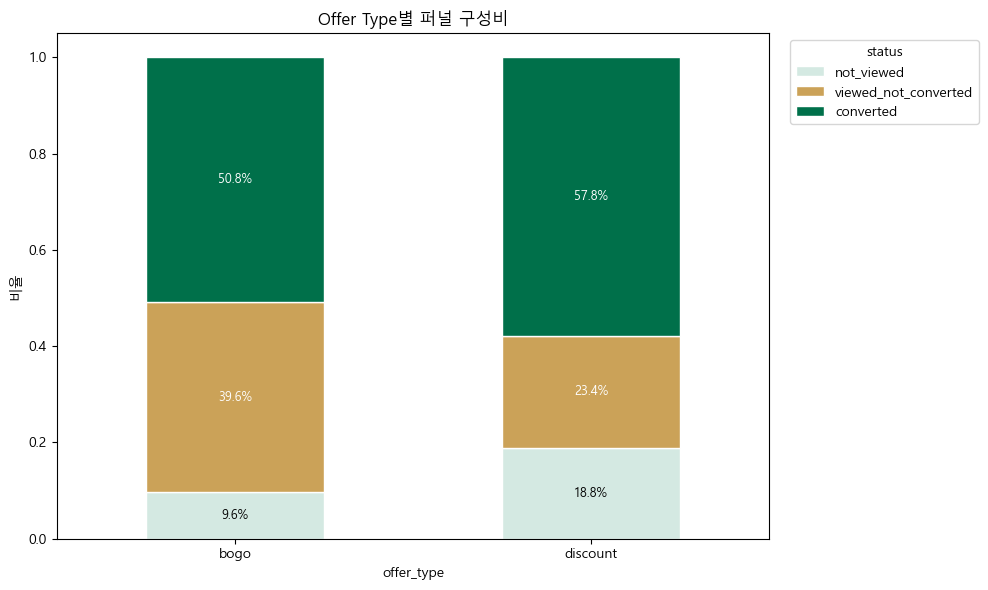

In [20]:
offer_type_ratio = make_status_summary(funnel_offer, 'offer_type')
display(offer_type_ratio)

plot_status_stacked_bar(
    offer_type_ratio,
    group_col='offer_type',
    title='Offer Type별 퍼널 구성비'
)

,offer_reward,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,2.0,15229,11388,9209,6763,0.747784,0.593871,0.604702
1,3.0,7646,7330,5108,4377,0.958671,0.597135,0.668062
2,5.0,22916,13988,11899,6992,0.610403,0.499857,0.519244
3,10.0,15251,13914,6936,5364,0.912334,0.385511,0.454790


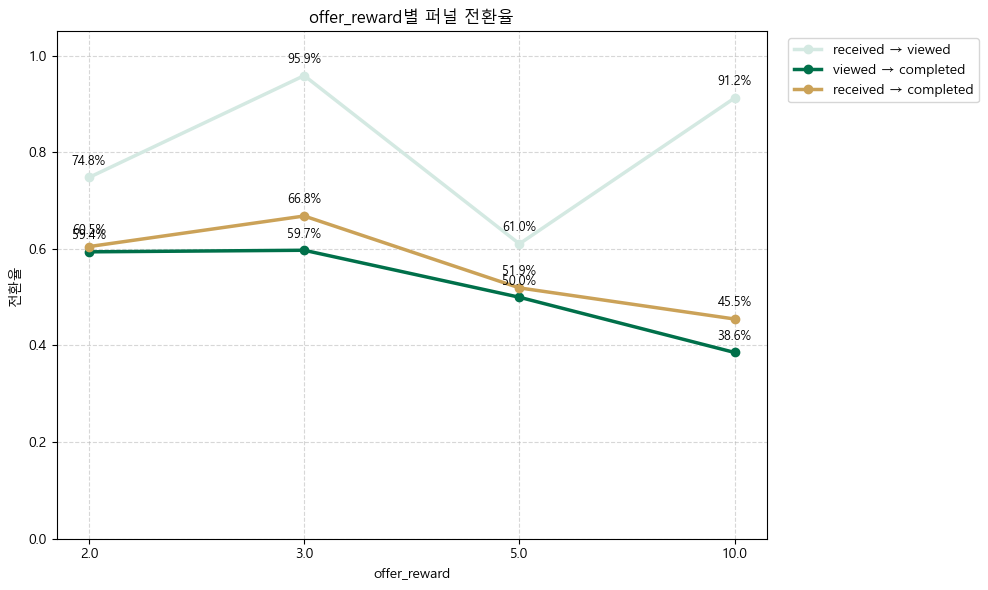

,difficulty,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,5.0,15248,11336,8565,5660,0.743442,0.499294,0.561713
1,7.0,7646,7330,5108,4377,0.958671,0.597135,0.668062
2,10.0,30480,25302,16145,12127,0.830118,0.479290,0.529692
3,20.0,7668,2652,3334,1332,0.345853,0.502262,0.434794


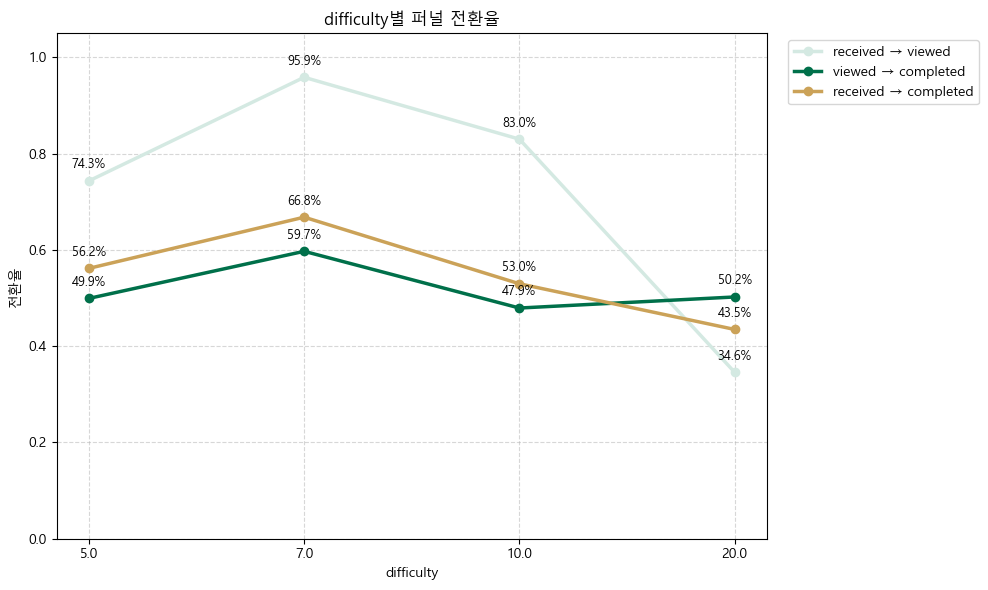

,duration,received,viewed,completed,completed_after_view,rv_rate,vc_rate,rc_rate
0,5.0,15164,14443,7563,6287,0.952453,0.435297,0.498747
1,7.0,30613,22198,17004,11242,0.725117,0.506442,0.555450
2,10.0,15265,9979,8585,5967,0.653718,0.597956,0.562398


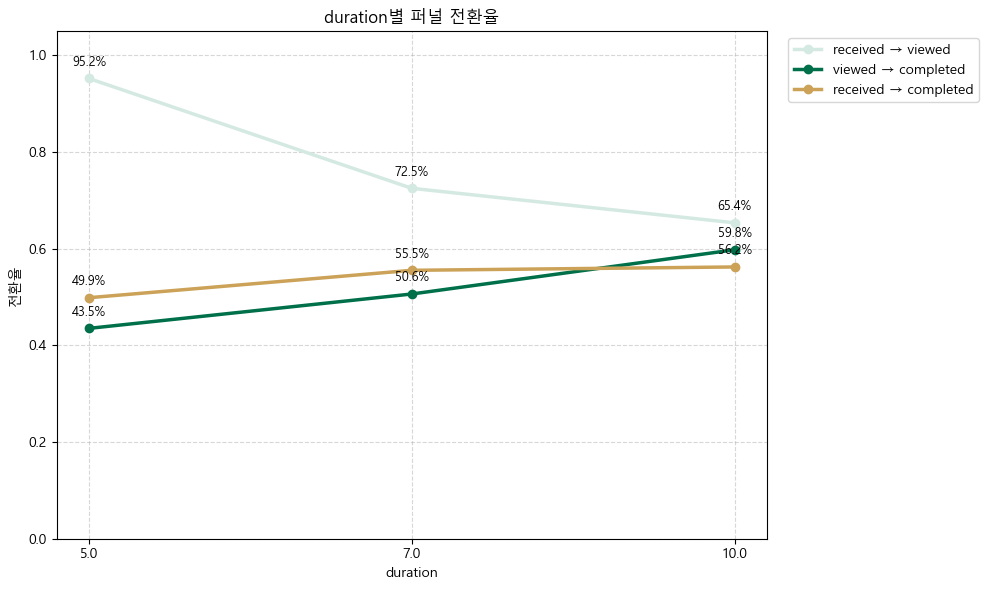

In [21]:
# ============================================================
# reward / difficulty / duration별 퍼널 전환율 요약 함수
# 각 그룹별 received, viewed, completed 개수를 집계
# 퍼널 단계별 전환율(rv_rate, vc_rate, rc_rate)을 계산
# ============================================================
def make_funnel_summary(df, group_col):

    # 그룹별 퍼널 단계 집계
    summary = df.groupby(group_col).agg(
        received=('customer_id', 'count'),                          # 전체 오퍼 수신 건수
        viewed=('has_viewed', 'sum'),                               # 열람 발생 건수
        completed=('has_completed_rc', 'sum'),                      # received 기준 완료 건수
        completed_after_view=('has_completed_after_view', 'sum')    # viewed 이후 완료 건수
    ).reset_index()

    # received → viewed 전환율
    summary['rv_rate'] = summary['viewed'] / summary['received']

    # viewed → completed 전환율
    summary['vc_rate'] = np.where(
        summary['viewed'] > 0,
        summary['completed_after_view'] / summary['viewed'],
        np.nan  # viewed가 0인 경우 0으로 나눌 수 없으므로 NaN 처리
    )

    # received → completed 전환율
    summary['rc_rate'] = summary['completed'] / summary['received']

    # 그룹 컬럼 기준 정렬 후 반환
    return summary.sort_values(group_col)



# ============================================================
# 퍼널 전환율 선그래프 함수
# rv_rate, vc_rate, rc_rate를 한 그래프에 함께 표시
# ============================================================
def plot_funnel_conversion(summary, group_col, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    # x축 위치 생성
    x = np.arange(len(summary))

    # received → viewed 전환율 선그래프
    ax.plot(
        x, summary['rv_rate'],
        marker='o',
        label='received → viewed',
        color='#D4E9E2',
        linewidth=2.5
    )                                       # 열람율: 매우 연한 청록
    ax.plot(
        x, summary['vc_rate'],
        marker='o',
        label='viewed → completed',
        color='#00704A',
        linewidth=2.5
    )                                       # 완료율: 진한 청록
    ax.plot(
        x, summary['rc_rate'],
        marker='o',
        label='received → completed',
        color='#CBA258',
        linewidth=2.5
    )                                       # 전환율: 스타벅스 골드


    for col in ['rv_rate', 'vc_rate', 'rc_rate']:
        for i, y in enumerate(summary[col]):
            if pd.notna(y):
                ax.text(
                    i, y + 0.02,              # 점보다 약간 위에 텍스트 표시
                    f'{y:.1%}',               # 퍼센트 형식으로 소수점 첫째 자리까지 출력
                    ha='center',              # 텍스트를 x좌표 기준 가운데 정렬
                    va='bottom',              # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
                    fontsize=9                # 글자 크기
                )

    # x축 눈금 및 라벨 설정
    ax.set_xticks(x)
    ax.set_xticklabels(summary[group_col])
    ax.set_ylim(0, 1.05)

    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel('전환율')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


# 컬럼별 퍼널 전환율 요약표 출력 및 그래프 생성
for col in ['offer_reward', 'difficulty', 'duration']:
    summary = make_funnel_summary(funnel_offer, col)
    display(summary)
    plot_funnel_conversion(
        summary,
        group_col=col,
        title=f'{col}별 퍼널 전환율'
    )

In [22]:
# 해석 주의: 상관계수 절대값이 작으면 통계적으로 유의하더라도 영향력은 제한적일 수 있음
# 오퍼 속성과 전환 간 상관계수
corr_df = funnel_offer[
    ['offer_reward', 'difficulty', 'duration', 'converted_rc']
].copy()

corr = corr_df.corr()

print("="*60)
print("상관계수 (Correlation)")
print("="*60)
display(corr)

상관계수 (Correlation)


,offer_reward,difficulty,duration,converted_rc
offer_reward,1.000000,0.063459,-0.455509,-0.126113
difficulty,0.063459,1.000000,0.643020,-0.093056
duration,-0.455509,0.643020,1.000000,0.041103
converted_rc,-0.126113,-0.093056,0.041103,1.000000


In [23]:
# 해석 주의: 표본 수가 커서 작은 평균 차이도 유의하게 나올 수 있으므로 효과크기(연관성)와 함께 봐야 함
# 전환 여부에 따른 차이 검정 (Welch t-test)
from scipy.stats import ttest_ind

print("="*60)
print("p-value (전환 여부에 따른 차이 검정)")
print("="*60)

for col in ['offer_reward', 'difficulty', 'duration']:
    group1 = funnel_offer[funnel_offer['converted_rc'] == 1][col]
    group0 = funnel_offer[funnel_offer['converted_rc'] == 0][col]

    stat, p = ttest_ind(group1, group0, equal_var=False)

    print(f"\n[{col}]")
    print(f"t-statistic: {stat:.4f}")
    print(f"p-value: {p:.6f}")

p-value (전환 여부에 따른 차이 검정)

[offer_reward]
t-statistic: -31.2580
p-value: 0.000000

[difficulty]
t-statistic: -22.8414
p-value: 0.000000

[duration]
t-statistic: 10.1534
p-value: 0.000000


In [24]:
# 해석 주의: 카이제곱 검정은 관련성 존재 여부를 보여주고, Cramér's V는 그 강도를 보여줌

# Offer Type vs Conversion 카이제곱 검정 + 연관성 크기 참고
from scipy.stats import chi2_contingency

ct = pd.crosstab(funnel_offer['offer_type'], funnel_offer['converted_rc'])

chi2, p, dof, expected = chi2_contingency(ct)

# 연관성 크기 참고: Cramér's V
n = ct.to_numpy().sum()
r, c = ct.shape
cramers_v = np.sqrt(chi2 / (n * min(r - 1, c - 1)))

if cramers_v < 0.1:
    interpretation = "매우 작은 연관성"
elif cramers_v < 0.3:
    interpretation = "작은 연관성"
elif cramers_v < 0.5:
    interpretation = "중간 연관성"
else:
    interpretation = "큰 연관성"

print("=" * 60)
print("Offer Type vs Conversion (카이제곱 검정)")
print("=" * 60)
print(f"chi2 statistic: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"degrees of freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")
print(f"연관성 해석: {interpretation}")
print()

print("[교차표]")
display(ct)

expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print("[기대빈도표]")
display(expected_df)


Offer Type vs Conversion (카이제곱 검정)
chi2 statistic: 298.1473
p-value: 0.000000
degrees of freedom: 1
Cramér's V: 0.0699
연관성 해석: 매우 작은 연관성

[교차표]


converted_rc,0,1
offer_type,,
bogo,14998,15501
discount,12892,17651


[기대빈도표]


converted_rc,0,1
offer_type,,
bogo,13934.948232,16564.051768
discount,13955.051768,16587.948232


## 해석
통계 검정 결과를 종합하면, 오퍼 속성과 전환 사이에 "차이는 존재"하지만 그 차이가 아주 강한 수준은 아니라고 보는 것이 맞다.

1. 상관계수
    - `offer_reward`와 전환: -0.126
    - `difficulty`와 전환: -0.093
    - `duration`과 전환: 0.041
- 절대값이 전반적으로 작기 때문에, 선형 관계는 크지 않다.

2. Welch t-test
    - reward, difficulty, duration 모두 p-value가 0.000000으로 매우 작다.
    - 다만 이는 표본 수가 큰 영향도 함께 받으므로, 실무적으로 큰 차이라고 바로 해석하면 안 된다.

3. Offer Type 카이제곱 검정
    - p-value는 0.000000으로 유의하다.
    - 그러나 Cramér's V는 0.0699로 `매우 작은 연관성` 수준이다.

즉, 오퍼 유형과 속성은 전환과 관련은 있지만, 그 자체만으로 전환을 강하게 설명하는 핵심 변수라고 보기는 어렵다.\ 
실무적으로는 오퍼 속성 하나만 최적화하기보다, 고객 세그먼트·채널·노출 이후 행동까지 함께 보는 것이 더 중요하다.

## 추가 보강이 필요한 요소
- reward 수준별 전환율의 p-value과 연관성
- difficulty 수준별 전환율의 p-value과 연관성
- duration 수준별 전환율의 p-value과 연관성

# 이주성



In [25]:
# 해석 주의: 열람 분석과 completed 분석의 기준 데이터가 다르므로 결과를 같은 모수처럼 직접 비교하면 안 됨
# ============================================================
# 이주성
# 세그먼트 / 프로모션 유형 / 세부 오퍼 분석
# 열람 분석은 informational 포함
# viewed → completed 분석은 completed 해석이 가능한 bogo / discount만 사용
# ============================================================

segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['~30대', '40대', '50대', '60대', '70대+', 'Missing'],
    'income_group': ['~4만', '4~6만', '6~8만', '8~10만', '10만+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}

# 프로모션 유형 순서 정의
offer_order = ['bogo', 'discount', 'informational']

# 열람 분석용: informational 포함
funnel_all = funnel.copy()

# viewed 이후 completed 분석용: informational 제외
funnel_viewed = funnel_all[funnel_all['converted_rv'] == 1].copy()
funnel_vc_main = funnel_viewed[funnel_viewed['offer_type'].isin(['bogo', 'discount'])].copy()

# 분석용 데이터 크기 확인
print('열람 분석용 데이터:', funnel_all.shape)
print('viewed → completed 분석용 데이터:', funnel_vc_main.shape)

열람 분석용 데이터: (76277, 38)
viewed → completed 분석용 데이터: (46620, 38)


---

In [26]:
# 해석 목적: 오퍼 유형별로 열람 단계 강점과 완료 단계 강점을 분리해서 확인함
# 프로모션 유형별 요약표
# - 열람률은 informational 포함
# - viewed → completed 전환률은 bogo / discount만 사용

# 프로모션 유형별 전체 퍼널 요약표 생성
offer_type_summary = (
    funnel_all
    .groupby('offer_type', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),               # 전체 오퍼 수신 건수
        viewed_cnt=('converted_rv', 'sum'),                 # received 이후 viewed 발생 건수
        completed_cnt=('converted_rc', 'sum'),              # received 이후 completed 발생 건수
        strict_completed_cnt=('converted_rvc', 'sum')       # received → viewed → completed까지 모두 이어진 건수
    )
    .reset_index()
)

# 퍼널 단계별 전환률 계산
# rv_rate  : received 대비 viewed 비율
# rc_rate  : received 대비 completed 비율
# rvc_rate : received → viewed → completed까지 모두 이어진 비율
offer_type_summary['rv_rate'] = offer_type_summary['viewed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rc_rate'] = offer_type_summary['completed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rvc_rate'] = offer_type_summary['strict_completed_cnt'] / offer_type_summary['received_cnt'] * 100

# 프로모션 유형 순서 고정
offer_type_summary['offer_type'] = pd.Categorical(
    offer_type_summary['offer_type'],
    categories=offer_order,
    ordered=True
)
# 지정한 순서 기준으로 정렬
offer_type_summary = offer_type_summary.sort_values('offer_type').reset_index(drop=True)

# 프로모션 유형별 viewed → completed 요약표 생성
offer_type_vc_summary = (
    funnel_vc_main
    .groupby('offer_type', dropna=False)
    .agg(
        viewed_cnt=('customer_id', 'size'),                 # 실제 viewed가 발생한 오퍼 건수
        completed_after_view_cnt=('converted_vc', 'sum'),   # viewed 이후 completed까지 이어진 건수
        avg_vc_time=('vc_time_diff', 'mean')                # viewed → completed 평균 소요 시간
    )
    .reset_index()
)

# viewed 대비 completed 전환률 계산
offer_type_vc_summary['vc_rate'] = (
    offer_type_vc_summary['completed_after_view_cnt'] /
    offer_type_vc_summary['viewed_cnt'] * 100
)


# 프로모션 유형 순서 고정
# viewed → completed 비교는 bogo / discount만 사용
offer_type_vc_summary['offer_type'] = pd.Categorical(
    offer_type_vc_summary['offer_type'],
    categories=['bogo', 'discount'],
    ordered=True
)
offer_type_vc_summary = offer_type_vc_summary.sort_values('offer_type').reset_index(drop=True)

display(offer_type_summary)
display(offer_type_vc_summary)

,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


## 해석
프로모션 유형별 성과를 보면, 열람 단계와 완료 단계의 강점이 서로 다르게 나타난다.

- 열람 단계(`received → viewed`)
    - `bogo`: 82.79%
    - `discount`: 69.97%
    - `informational`: 65.29%

- 완료 단계(`received → completed`)
    - `discount`: 57.79%
    - `bogo`: 50.82%
    - `informational`: 0.00% (`informational`은 구조상 completed 해석 대상이 아님)

- 열람 이후 완료 전환(`viewed → completed`)
    - `discount`: 58.36%
    - `bogo`: 43.66%

즉, `bogo`는 고객이 오퍼를 열어보게 만드는 힘이 더 강하고,\
`discount`는 한 번 본 고객이 실제 완료까지 이어질 가능성이 더 높다.

따라서 "노출/열람을 늘릴 것인지", "열람 후 완료를 밀어줄 것인지"에 따라 유형별 역할을 다르게 배치하는 해석이 가능하다.

---

## 세그먼트별 전체 반응률 요약표

In [27]:
# ============================================================
# 세그먼트별 전체 열람률 요약 함수
# ============================================================
def make_segment_rv_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),   # 세그먼트별 전체 오퍼 수신 건수
            viewed_cnt=('converted_rv', 'sum')      # 세그먼트별 열람된 오퍼 건수
        )
        .reset_index()
    )

    # 열람률 계산
    # 열람된 오퍼 건수 / 전체 오퍼 수신 건수 * 100
    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100

    # 세그먼트 구성비 계산
    # 전체 오퍼 수신 건수 중 해당 세그먼트가 차지하는 비율
    summary['segment_share'] = summary['received_cnt'] / summary['received_cnt'].sum() * 100

    # 지정한 세그먼트 순서가 있으면 범주형 순서 적용
    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        summary = summary.sort_values(segment_col).reset_index(drop=True)

    return summary

In [28]:
#  ============================================================
# 세그먼트 × offer_type 열람률 요약 함수
# ============================================================
def make_segment_offer_rv_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),   # 세그먼트 × 오퍼유형별 전체 오퍼 수신 건수
            viewed_cnt=('converted_rv', 'sum')      # 세그먼트 × 오퍼유형별 열람된 오퍼 건수
        )
        .reset_index()
    )

    # 열람률 계산
    # 열람된 오퍼 건수 / 전체 오퍼 수신 건수 * 100
    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100

    # 세그먼트 순서 지정
    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )

    # 오퍼 유형 순서 지정
    summary['offer_type'] = pd.Categorical(
        summary['offer_type'],
        categories=offer_order,
        ordered=True
    )

    # 세그먼트, 오퍼 유형 순서대로 정렬
    summary = summary.sort_values([segment_col, 'offer_type']).reset_index(drop=True)
    return summary

In [29]:
# ============================================================
# 세그먼트 × offer_type 점-선 그래프
# 세그먼트별로 프로모션 유형 열람률(rv_rate)을 비교
# ============================================================
def plot_segment_offer_point(summary_df, segment_col, group_title, exclude_groups=None):

    # 원본 데이터 훼손 방지를 위해 복사
    df_a = summary_df.copy()

    # 범주형/결측 처리 과정에서 타입 충돌을 줄이기 위해 문자열로 변환
    df_a[segment_col] = df_a[segment_col].astype(str)
    df_a['offer_type'] = df_a['offer_type'].astype(str)

    # 제외할 세그먼트 그룹이 있으면 제거
    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    # 세그먼트 순서 지정
    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].unique()]
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=order_list,
            ordered=True
        )

    # 프로모션 유형 순서 지정
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )

    # 세그먼트, 프로모션 유형 기준 정렬
    df_a = df_a.sort_values([segment_col, 'offer_type'])

    # 점-선 그래프 생성
    plt.figure(figsize=(9, 5))
    sns.pointplot(
        data=df_a,
        x='offer_type',      # x축: 프로모션 유형
        y='rv_rate',         # y축: 열람률(%)
        hue=segment_col,     # 선 구분: 세그먼트 그룹
        order=offer_order,
        dodge=0.25,          # 점이 겹치지 않도록 약간 좌우로 분리
        markers='o',
        linestyles='-'
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title(f'[{group_title}] 세그먼트별 프로모션 유형 열람률 비교')
    plt.xlabel('프로모션 유형')
    plt.ylabel('열람률 (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title=segment_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [30]:
# ============================================================
# 세그먼트별 received 건수 막대그래프 함수
# 세그먼트별 전체 오퍼 수신 건수(received_cnt)를 합산
# ============================================================
def plot_segment_received_count(summary_df, segment_col, group_title, exclude_groups=None):

    # 원본 데이터 훼손 방지를 위해 복사
    df_a = summary_df.copy()

    # 범주형/결측 처리 과정에서 타입 충돌을 줄이기 위해 문자열로 변환
    df_a[segment_col] = df_a[segment_col].astype(str)

    # 제외할 세그먼트 그룹이 있으면 제거
    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()


    # 세그먼트별 received 건수 합산
    # 세그먼트 × offer_type 요약표가 들어온 경우 세그먼트 기준으로 다시 합산
    count_df = (
        df_a.groupby(segment_col, as_index=False)['received_cnt']
        .sum()
    )

    # 정렬과 시각화를 위해 문자열 형태로 다시 통일
    count_df[segment_col] = count_df[segment_col].astype(str)

    # 세그먼트 순서 지정
    # 그래프 x축이 보기 좋은 순서로 나오도록 설정
    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in count_df[segment_col].unique()]
        count_df[segment_col] = pd.Categorical(
            count_df[segment_col],
            categories=order_list,
            ordered=True
        )
        count_df = count_df.sort_values(segment_col)

    # 순서형 그래프용 색상 지정
    repeat_n = (len(count_df) // len(base_colors)) + 1
    ordered_colors = (base_colors * repeat_n)[:len(count_df)]

    # 막대그래프 생성
    plt.figure(figsize=(8, 4))
    bars = plt.bar(
        count_df[segment_col].astype(str),
        count_df['received_cnt'],
        color=ordered_colors,
        edgecolor='white'
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title(f'[{group_title}] 세그먼트별 received 건수')
    plt.xlabel(segment_col)
    plt.ylabel('received_cnt')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 막대 위에 received 건수 표시
    for bar, v in zip(bars, count_df['received_cnt']):
        plt.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            v,                                   # y좌표: 막대 높이 위치
            f'{int(v):,}',                       # 표시할 텍스트: 천 단위 콤마 포함 정수
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    # 레이아웃 정리 후 그래프 출력
    plt.tight_layout()
    plt.show()

In [32]:
# 해석 주의: Missing 그룹은 고객 특성 자체가 아니라 정보 부재 상태이므로 본문 결론에서는 보조적으로만 다룸
# 열람 단계 핵심 요약표
# - 본문에서는 연령대 / 소득대 중심으로 해석

gender_rv_summary = make_segment_rv_summary(funnel_all, 'gender_group')
age_rv_summary = make_segment_rv_summary(funnel_all, 'age_group')
income_rv_summary = make_segment_rv_summary(funnel_all, 'income_group')
cohort_rv_summary = make_segment_rv_summary(funnel_all, 'member_cohort')

gender_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'gender_group')
age_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'age_group')
income_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'income_group')
cohort_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'member_cohort')

In [33]:
print('=' * 70)
print('열람 단계 핵심 요약표')
print('=' * 70)
print('[연령대별 열람률]')
display(age_rv_summary)
print('[소득대별 열람률]')
display(income_rv_summary)
print('[성별별 열람률 - 보조]')
display(gender_rv_summary)
print('[가입코호트별 열람률 - 보조]')
display(cohort_rv_summary)


열람 단계 핵심 요약표
[연령대별 열람률]


,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~30대,7688,5227,67.989074,10.079054
1,40대,7202,5203,72.243821,9.441903
2,50대,10626,8206,77.225673,13.930805
3,60대,16177,11943,73.827038,21.208228
4,70대+,24808,18264,73.621412,32.523565
5,Missing,9776,7724,79.009820,12.816445


[소득대별 열람률]


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~4만,9667,6514,67.383883,12.673545
1,4~6만,20458,14986,73.252517,26.820667
2,6~8만,20415,15525,76.047024,26.764293
3,8~10만,11435,8945,78.224749,14.991413
4,10만+,4526,2873,63.477684,5.933637
5,Missing,9776,7724,79.009820,12.816445


[성별별 열람률 - 보조]


,gender_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,F,27456,20295,73.918269,35.995123
1,M,38129,27779,72.855307,49.987545
2,O,916,769,83.951965,1.200886
3,Missing,9776,7724,79.009820,12.816445


[가입코호트별 열람률 - 보조]


,member_cohort,received_cnt,viewed_cnt,rv_rate,segment_share
0,2013-2014,4199,3097,73.755656,5.504936
1,2015-2016,20670,15366,74.339623,27.098601
2,2017-2018,41632,30380,72.972713,54.580018
3,Missing,9776,7724,79.009820,12.816445


In [34]:
print('=' * 70)
print('전체 반응률')
print('=' * 70)
print("[gender 전체 반응률]")
display(gender_rv_summary)
print("[age_group 전체 반응률]")
display(age_rv_summary)
print("[income_group 전체 반응률]")
display(income_rv_summary)
print("[member_cohort 전체 반응률]")
display(cohort_rv_summary)


전체 반응률
[gender 전체 반응률]


,gender_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,F,27456,20295,73.918269,35.995123
1,M,38129,27779,72.855307,49.987545
2,O,916,769,83.951965,1.200886
3,Missing,9776,7724,79.009820,12.816445


[age_group 전체 반응률]


,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~30대,7688,5227,67.989074,10.079054
1,40대,7202,5203,72.243821,9.441903
2,50대,10626,8206,77.225673,13.930805
3,60대,16177,11943,73.827038,21.208228
4,70대+,24808,18264,73.621412,32.523565
5,Missing,9776,7724,79.009820,12.816445


[income_group 전체 반응률]


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,~4만,9667,6514,67.383883,12.673545
1,4~6만,20458,14986,73.252517,26.820667
2,6~8만,20415,15525,76.047024,26.764293
3,8~10만,11435,8945,78.224749,14.991413
4,10만+,4526,2873,63.477684,5.933637
5,Missing,9776,7724,79.009820,12.816445


[member_cohort 전체 반응률]


,member_cohort,received_cnt,viewed_cnt,rv_rate,segment_share
0,2013-2014,4199,3097,73.755656,5.504936
1,2015-2016,20670,15366,74.339623,27.098601
2,2017-2018,41632,30380,72.972713,54.580018
3,Missing,9776,7724,79.009820,12.816445


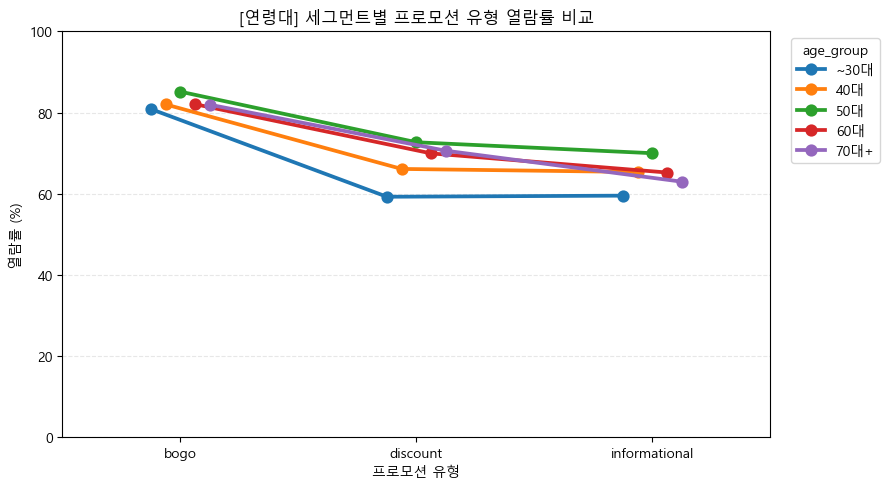

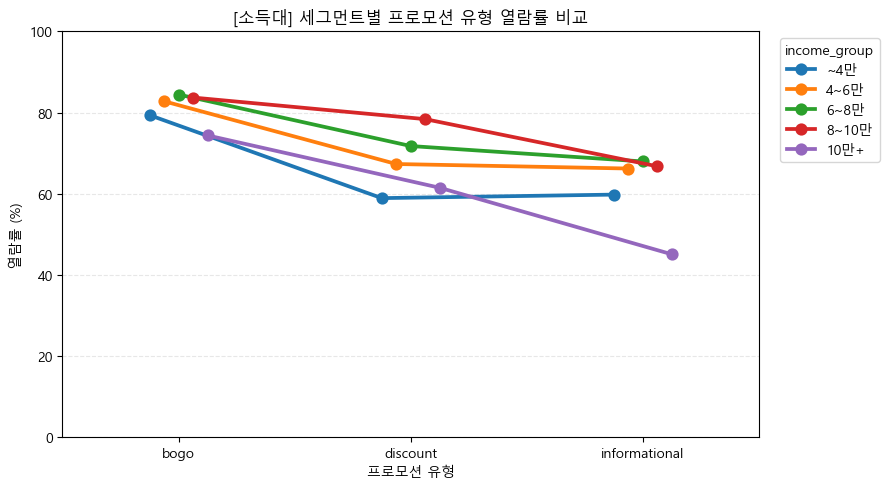

In [35]:
# plot_segment_offer_point(gender_offer_rv_summary, 'gender_group', '성별', exclude_groups=['Missing'])
plot_segment_offer_point(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_offer_point(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
# plot_segment_offer_point(cohort_offer_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

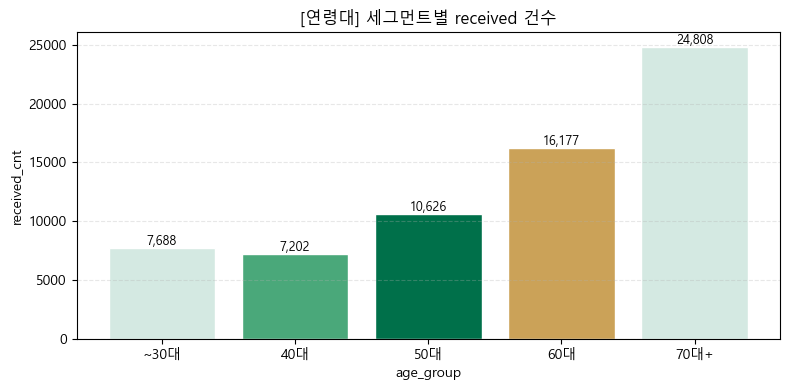

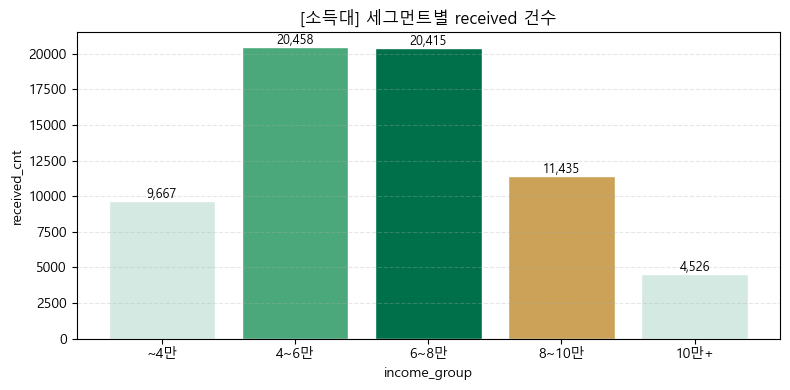

In [36]:
# plot_segment_received_count(gender_rv_summary, 'gender_group', '성별')
plot_segment_received_count(age_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
plot_segment_received_count(income_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
# plot_segment_received_count(cohort_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

## 해석
세그먼트별 전체 열람률을 보면, 고객 특성에 따라 차이가 나타나지만   그 차이의 크기는 변수마다 다르다.

1. 연령대
    - `~30대`: 67.99%
    - `40대`: 72.24%
    - `50대`: 77.23%
    - `60대`: 73.83%
    - `70대+`: 73.62%
- `50대`가 가장 높고 `~30대`가 가장 낮다.\
너무 어린 구간보다 중장년 구간에서 오퍼 열람이 더 잘 일어나는 패턴이 보인다.

2. 소득대
    - `~4만`: 67.38%
    - `4~6만`: 73.25%
    - `6~8만`: 76.05%
    - `8~10만`: 78.22%
    - `10만+`: 63.48%
- 중간~중상 소득 구간의 열람률이 높고, `10만+`는 오히려 낮다.\
따라서 고소득층이 항상 오퍼를 잘 보는 것은 아니며, 일정 수준의 실속형 고객층에서 반응이 더 좋은 것으로 해석할 수 있다.

3. 성별 / 가입 코호트
    - 성별 차이는 크지 않다. `F` 73.92%, `M` 72.86%
    - 가입 코호트도 큰 격차보다는 완만한 차이에 가깝다.

> `Missing` 그룹은 고객 정보 부재 집단이므로, 열람률이 높게 나와도 실질적인 고객 특성으로 해석하지 않는 것이 맞다.

---

## 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?

In [37]:
# ============================================================
# 세그먼트별 프로모션 유형 열람률 비교 그래프
# 세그먼트별 전체 오퍼 수신 건수(received_cnt)를 막대그래프로 시각화
# ============================================================
def plot_segment_offer_rv_bar(summary_df, segment_col, group_title, exclude_groups=None):

    # 원본 데이터 훼손 방지를 위해 복사
    df_a = summary_df.copy()

    # 제외할 세그먼트 그룹이 있으면 제거
    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].astype(str).isin(exclude_groups)].copy()

    # 시각화 전 문자열 형태로 통일
    df_a[segment_col] = df_a[segment_col].astype(str)

    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].tolist()]
        df_a[segment_col] = pd.Categorical(df_a[segment_col], categories=order_list, ordered=True)

    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'].astype(str),
        categories=offer_order,
        ordered=True
    )

    df_a = df_a.sort_values([segment_col, 'offer_type'])

    # 프로모션 유형별 색상 지정
    palette_map = {
        'bogo': '#00704A',
        'discount': '#4AA87A',
        'informational': '#D4E9E2'
    }

    # 막대그래프 생성
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(
        data=df_a,
        x=segment_col,      # x축: 세그먼트 그룹
        y='rv_rate',        # y축: 열람률(%)
        hue='offer_type',   # 색상 구분: 프로모션 유형
        hue_order=offer_order,
        palette=palette_map
    )

    plt.title(f'[{group_title}] 프로모션 유형별 열람률 비교')
    plt.xlabel(group_title)
    plt.ylabel('rv_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(title='offer_type', bbox_to_anchor=(1.02, 1), loc='upper left')

    for container in ax.containers:
        labels = []
        for bar in container:
            h = bar.get_height()
            labels.append(f'{h:.1f}' if pd.notna(h) and h > 0 else '')
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)

    plt.tight_layout()
    plt.show()

In [38]:
# ============================================================
# 세그먼트별 요약표 생성
# ============================================================
gender_rv_summary = make_segment_rv_summary(funnel_all, 'gender_group')
age_rv_summary = make_segment_rv_summary(funnel_all, 'age_group')
income_rv_summary = make_segment_rv_summary(funnel_all, 'income_group')
cohort_rv_summary = make_segment_rv_summary(funnel_all, 'member_cohort')

gender_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'gender_group')
age_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'age_group')
income_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'income_group')
cohort_offer_rv_summary = make_segment_offer_rv_summary(funnel_all, 'member_cohort')

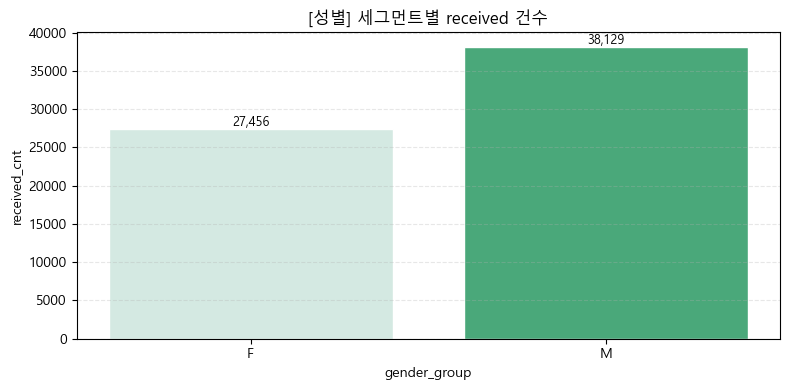

In [39]:
plot_segment_received_count(gender_rv_summary, 'gender_group', '성별', exclude_groups=['O','Missing'])
# plot_segment_received_count(age_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
# plot_segment_received_count(income_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
# plot_segment_received_count(cohort_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

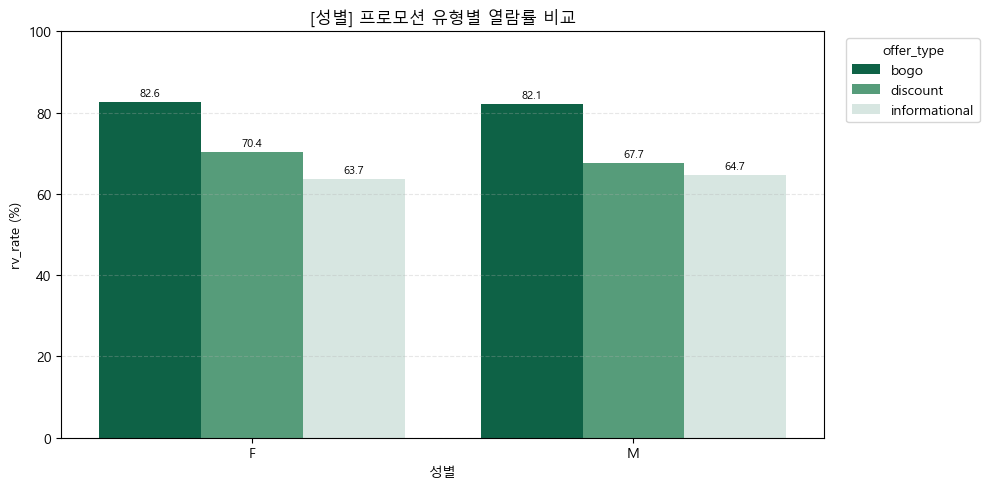

In [40]:
plot_segment_offer_rv_bar(gender_offer_rv_summary, 'gender_group', '성별', exclude_groups=['O','Missing'])
# plot_segment_offer_rv_bar(age_offer_rv_summary, 'age_group', '연령대', exclude_groups=['Missing'])
# plot_segment_offer_rv_bar(income_offer_rv_summary, 'income_group', '소득대', exclude_groups=['Missing'])
# plot_segment_offer_rv_bar(cohort_offer_rv_summary, 'member_cohort', '가입 코호트', exclude_groups=['Missing'])

## 해석
성별 기준 보조 그래프에서는 `F`와 `M`의 전체 열람률 차이가 아주 크지는 않지만,\
프로모션 유형별로 나눠 보면 반응 패턴의 미세한 차이를 확인할 수 있다.

다만, 이번 노트북의 핵심 결론은 성별 자체보다 연령대와 소득대에서 더 뚜렷한 차이가 나타났다는 점에 있다.\
따라서 성별 그래프는 보조 근거로 두고, 실제 전략 분기는 연령대·소득대·가입기간 쪽에 더 무게를 두는 것이 적절하다 판단된다.

---

## viewed → completed 전환 분석

In [41]:
# viewed → completed 전환률 요약 함수
# 세그먼트별 viewed 건수, viewed 이후 completed 건수, 평균 소요시간을 집계
def make_segment_vc_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),                 # 세그먼트별 실제 viewed가 발생한 오퍼 건수
            completed_after_view_cnt=('converted_vc', 'sum'),   # viewed 이후 completed까지 이어진 건수
            avg_vc_time=('vc_time_diff', 'mean')                # viewed → completed 평균 소요 시간
        )
        .reset_index()
    )

    # viewed → completed 전환률 계산
    # viewed 이후 completed까지 이어진 건수 / 실제 viewed가 발생한 오퍼 건수 * 100
    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100

    # 세그먼트 순서 지정
    # 그래프와 요약표에서 보기 좋은 순서로 정렬
    if segment_col in segment_order_map:
        summary[segment_col] = pd.Categorical(
            summary[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        summary = summary.sort_values(segment_col).reset_index(drop=True)

    return summary


# ============================================================
# 세그먼트별 viewed → completed 전환률 막대그래프 함수
# 세그먼트별 vc_rate를 막대그래프로 시각화
# ============================================================
def plot_segment_vc_bar(summary_df, segment_col, group_title, exclude_groups=None):
    # 원본 데이터 훼손 방지를 위해 복사
    df_a = summary_df.copy()

    # 제외할 세그먼트 그룹이 있으면 제거
    if exclude_groups is not None:
        df_a = df_a[~df_a[segment_col].isin(exclude_groups)].copy()

    # 정렬 순서 고정
    if segment_col in segment_order_map:
        order_list = [x for x in segment_order_map[segment_col] if x in df_a[segment_col].astype(str).tolist()]
        df_a[segment_col] = df_a[segment_col].astype(str)
        df_a = df_a[df_a[segment_col].isin(order_list)].copy()
        df_a[segment_col] = pd.Categorical(df_a[segment_col], categories=order_list, ordered=True)
        df_a = df_a.sort_values(segment_col)

    # 막대그래프 생성
    plt.figure(figsize=(9, 4.5))
    sns.barplot(
        data=df_a,
        x=segment_col,   # x축: 세그먼트 그룹
        y='vc_rate'      # y축: viewed → completed 전환률(%)
    )


    # 그래프 제목 및 축 라벨 설정
    plt.title(f'[{group_title}] 고객군별 viewed → completed 전환률')
    plt.xlabel(segment_col)
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 막대 위에 전환률 값 표시
    for i, v in enumerate(df_a['vc_rate']):
        plt.text(
            i,                                   # x좌표: 각 막대의 중심 위치
            v + 0.5,                             # y좌표: 막대 높이보다 조금 위에 표시
            f'{v:.1f}',                          # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    plt.tight_layout()
    plt.show()

In [42]:
# viewed → completed 전환율
# completed 해석이 가능한 bogo, discount만 사용

gender_vc_summary = make_segment_vc_summary(funnel_vc_main, 'gender_group')
age_vc_summary = make_segment_vc_summary(funnel_vc_main, 'age_group')
income_vc_summary = make_segment_vc_summary(funnel_vc_main, 'income_group')
cohort_vc_summary = make_segment_vc_summary(funnel_vc_main, 'member_cohort')

print('=' * 70)
print('viewed → completed 핵심 요약표')
print('=' * 70)
display(gender_vc_summary)
display(age_vc_summary)
display(income_vc_summary)
display(cohort_vc_summary)

viewed → completed 핵심 요약표


,gender_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,F,16765,10507,40.514133,62.672234
1,M,22881,11655,47.171686,50.937459
2,O,612,390,41.646154,63.725490
3,Missing,6362,944,81.165254,14.838101


,age_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,~30대,4333,1953,47.794163,45.072698
1,40대,4268,2267,44.911337,53.116214
2,50대,6716,3779,44.921408,56.268612
3,60대,9807,5734,42.304499,58.468441
4,70대+,15134,8819,43.567525,58.272763
5,Missing,6362,944,81.165254,14.838101


,income_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,~4만,5390,2322,51.361757,43.079777
1,4~6만,12227,6231,47.049591,50.960988
2,6~8만,12756,7505,42.722718,58.835058
3,8~10만,7413,4826,41.035226,65.101848
4,10만+,2472,1668,36.338129,67.475728
5,Missing,6362,944,81.165254,14.838101


,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2013-2014,2550,1427,55.286615,55.960784
1,2015-2016,12659,9209,36.243675,72.746662
2,2017-2018,25049,11916,48.594159,47.570761
3,Missing,6362,944,81.165254,14.838101


## 해석

`viewed → completed` 단계에서는 열람 이후 실제 완료까지 이어지는 힘이   세그먼트별로 더 뚜렷하게 갈린다.

1. 성별
    - `F`: 62.67%
    - `M`: 50.94%
- 열람 이후 완료 전환은 여성 고객 쪽이 더 높게 나타났다.

2. 연령대
    - `~30대`: 45.07%
    - `40대`: 53.12%
    - `50대`: 56.27%
    - `60대`: 58.47%
    - `70대+`: 58.27%
- 열람 이후 완료는 연령이 높아질수록 전반적으로 좋아지는 흐름을 보인다.

3. 소득대
    - `~4만`: 43.08%
    - `4~6만`: 50.96%
    - `6~8만`: 58.84%
    - `8~10만`: 65.10%
    - `10만+`: 67.48%
- 소득이 높을수록 완료 전환이 강해지는 패턴이 뚜렷하다.\ 
즉, 열람 자체는 중간 소득층이 강했지만, 열람 후 실제 완료까지 이어지는 힘은 고소득층이 더 높다고 해석할 수 있다.

4. 가입 코호트
    - `2015-2016`: 72.75%
    - `2017-2018`: 47.57%
- `2015-2016` 코호트는 완료 전환률이 높고 가입 시점별 차이도 크다 볼수 있다.

참고로 `Missing`은 평균 소요시간이 81.17시간, 전환률은 14.84%로 매우 낮다.\
이 역시 고객 특성이라기보다 정보 부재 집단의 불안정성으로 보는 것이 적절하다.

---

## 프로모션 유형별 비교

In [43]:
# 프로모션 유형별 비교 그래프
def plot_offer_type_rv(summary_df):
    df_a = summary_df.copy()
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount', 'informational'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    palette_map = {
        'bogo': '#00704A',
        'discount': '#4AA87A',
        'informational': '#D4E9E2'
    }

    # 그래프 제목 및 축 라벨 설정
    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(
        data=df_a,
        x='offer_type',
        y='rv_rate',
        hue='offer_type',
        palette=palette_map,
        legend=False,
        dodge=False
    )

    # 막대 위에 열람률 값 표시
    for i, v in enumerate(df_a['rv_rate']):
        plt.text(
            i,                                   # x좌표: 각 막대의 중심 위치
            v + 0.5,                             # y좌표: 막대 높이보다 조금 위에 표시
            f'{v:.1f}',                          # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    # 레이아웃 정리 후 그래프 출력
    plt.tight_layout()
    plt.xlabel('프로모션 유형')
    plt.ylabel('전환률 (%)')
    plt.show()

# ============================================================
# 프로모션 유형별 viewed → completed 전환률 비교 그래프 함수
# completed 해석이 가능한 bogo / discount만 사용
# 프로모션 유형별 vc_rate를 막대그래프로 시각화
# ============================================================
def plot_offer_type_vc(summary_df):
    # 원본 데이터 훼손 방지를 위해 복사
    df_a = summary_df.copy()

    # informational 제외
    df_a = df_a[df_a['offer_type'].isin(['bogo', 'discount'])].copy()

    # 프로모션 유형 순서 지정
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=['bogo', 'discount'],
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')

    # 프로모션 유형별 색상 지정
    palette_map = {
        'bogo': '#00704A',
        'discount': '#4AA87A'
    }

    # 막대그래프 생성
    plt.figure(figsize=(7, 4.5))
    ax = sns.barplot(
        data=df_a,
        x='offer_type',     # x축: 프로모션 유형
        y='vc_rate',        # y축: viewed → completed 전환률(%)
        hue='offer_type',   # 색상 구분: 프로모션 유형
        palette=palette_map,
        legend=False,
        dodge=False
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title('프로모션 유형별 viewed → completed 전환률 비교')
    plt.xlabel('offer_type')
    plt.ylabel('vc_rate (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 막대 위에 전환률 값 표시
    for i, v in enumerate(df_a['vc_rate']):
        plt.text(
            i,                                   # x좌표: 각 막대의 중심 위치
            v + 0.5,                             # y좌표: 막대 높이보다 조금 위에 표시
            f'{v:.1f}',                          # 표시할 텍스트: 소수점 첫째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=9                           # 글자 크기
        )

    # 레이아웃 정리 후 그래프 출력
    plt.tight_layout()
    plt.xlabel('프로모션 유형')
    plt.ylabel('전환률 (%)')
    plt.show()

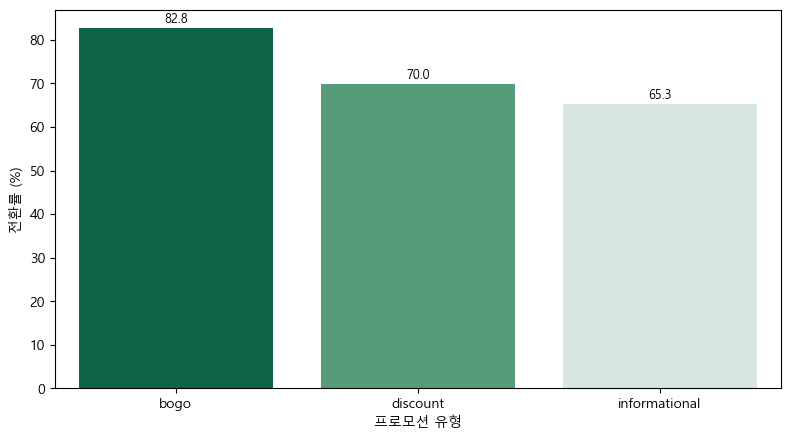

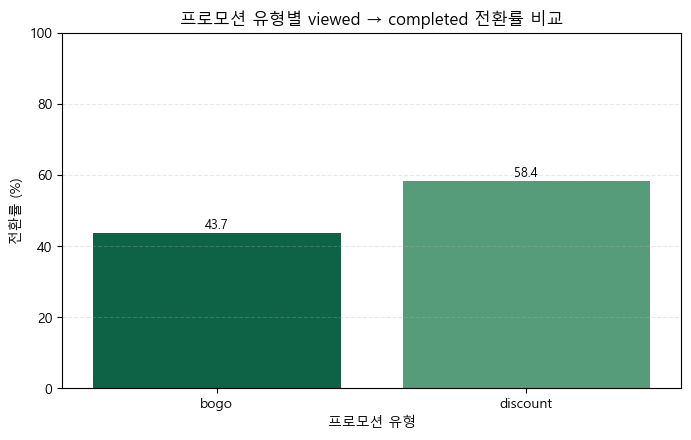

In [44]:
plot_offer_type_rv(offer_type_summary)
plot_offer_type_vc(offer_type_vc_summary)

## 해석
프로모션 유형별 비교를 다시 정리하면 다음과 같다.

- `bogo`: 열람 단계 강세
- `discount`: 완료 단계 강세
- `informational`: 인지도/열람 확인용 보조 유형

즉, 같은 "성과 좋은 오퍼"라도 어떤 목표를 두느냐에 따라 적합한 유형이 달라진다.

- 고객이 오퍼를 보게 만드는 것이 목표라면 `bogo`
- 본 뒤 실제 조건 충족까지 밀어주는 것이 목표라면 `discount`

---

## 세부 오퍼 비교 (보조 근거)

In [45]:
# 해석 목적: 같은 offer_type 안에서도 세부 offer_id 성과 차이가 있는지 확인해 전략 우선순위를 잡기 위함
# ============================================================
# 프로모션 유형별 세부 오퍼 성과 요약표 생성
# offer_type + offer_id 기준으로 오퍼별 퍼널 성과를 집계
# bogo / discount는 rvc_rate 기준 상위 오퍼 확인
# informational은 completed 해석이 어려우므로 rv_rate 기준 상위 오퍼 확인
# ============================================================
offer_detail_summary = (
    funnel_all
    .groupby(['offer_type', 'offer_id'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),       # 오퍼별 전체 수신 건수
        viewed_cnt=('converted_rv', 'sum'),         # 오퍼별 열람 건수
        completed_cnt=('converted_rc', 'sum'),      # 오퍼별 completed 건수
        strict_completed_cnt=('converted_rvc', 'sum')  # 오퍼별 received→viewed→completed 건수
    )
    .reset_index()
)

# 오퍼별 퍼널 전환률 계산
# rv_rate  : received 대비 viewed 비율
# rc_rate  : received 대비 completed 비율
# rvc_rate : received → viewed → completed까지 모두 이어진 비율
offer_detail_summary['rv_rate'] = offer_detail_summary['viewed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rc_rate'] = offer_detail_summary['completed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rvc_rate'] = offer_detail_summary['strict_completed_cnt'] / offer_detail_summary['received_cnt'] * 100


# bogo 유형 상위 오퍼 추출
# 최종 퍼널 흐름이 모두 이어진 rvc_rate 기준으로 상위 3개 선택
top_bogo = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'bogo']
    .sort_values('rvc_rate', ascending=False)
    .head(3)
)

# discount 유형 상위 오퍼 추출
# 최종 퍼널 흐름이 모두 이어진 rvc_rate 기준으로 상위 3개 선택
top_discount = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'discount']
    .sort_values('rvc_rate', ascending=False)
    .head(3)
)

# informational 유형 상위 오퍼 추출
# informational은 completed 해석이 어렵기 때문에 rv_rate 기준으로 상위 3개 선택
top_info = (
    offer_detail_summary[offer_detail_summary['offer_type'] == 'informational']
    .sort_values('rv_rate', ascending=False)
    .head(3)
)

# 결과 출력
print('[bogo 상위 오퍼]')
display(top_bogo[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])

print('[discount 상위 오퍼]')
display(top_discount[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate', 'rvc_rate']])

print('[informational 상위 오퍼]')
display(top_info[['offer_id', 'received_cnt', 'rv_rate', 'rc_rate']])

[bogo 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
3,f19421c1d4aa40978ebb69ca19b0e20d,7571,95.205389,56.293752,46.704530
0,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,95.285131,43.474253,36.230739
2,ae264e3637204a6fb9bb56bc8210ddfd,7658,87.215983,47.466701,34.121180


[discount 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate,rvc_rate
7,fafdcd668e3743c1bb461111dcafc2a4,7597,96.445966,69.119389,61.010925
5,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,95.867120,66.806173,57.245619
6,2906b810c7d4411798c6938adc9daaa5,7632,53.210168,51.860587,27.882600


[informational 상위 오퍼]


,offer_id,received_cnt,rv_rate,rc_rate
9,5a8bc65990b245e5a138643cd4eb9837,7618,80.716724,0.0
8,3f207df678b143eea3cee63160fa8bed,7617,49.862150,0.0


## 해석
같은 프로모션 유형 안에서도 세부 오퍼별 성과 차이는 분명하게 나타난다.

1. bogo
    - `f19421c1d4aa40978ebb69ca19b0e20d`: `rvc_rate` 46.70%
    - `4d5c57ea9a6940dd891ad53e9dbe8da0`: 36.23%
    - `ae264e3637204a6fb9bb56bc8210ddfd`: 34.12%
- 같은 bogo라도 약 10%p 이상 차이가 나며 유형만 보고 묶기보다 개별 오퍼 단위 성과를 따로 보는 것이 필요하다.

2. discount
    - `fafdcd668e3743c1bb461111dcafc2a4`: `rvc_rate` 61.01%
    - `2298d6c36e964ae4a3e7e9706d1fb8c2`: 57.25%
    - `2906b810c7d4411798c6938adc9daaa5`: 27.88%
- discount 안에서도 상위 오퍼와 하위 오퍼의 격차가 매우 크다.\
특히 `2906...`는 열람률 53.21%, `rvc_rate` 27.88%로 상대적으로 약하다.

3. informational
    - `5a8bc65990b245e5a138643cd4eb9837`: 열람률 80.72%
    - `3f207df678b143eea3cee63160fa8bed`: 열람률 49.86%
- informational은 completed 대신 열람률 기준으로 차이를 보는 것이 맞으며,\
이 역시 세부 오퍼별 성과 차이가 매우 크다.

결론적으로 실무 전략은 `offer_type` 수준에서 한 번 나누고,\
최종 실행 우선순위는 `offer_id` 수준에서 다시 정교화하는 방식이 적절하다.

# 공용 분석

- 전체 분포: 전환 완료 / 열람 후 미전환 / 미열람
- 전체 퍼널 전환율: received → viewed, viewed → completed, received → completed

In [46]:
# ============================================================
# 전체 전환 분포 표
# converted: 최종 완료
# viewed_not_converted: 열람은 했지만 완료는 못함
# not_viewed: 열람하지 않음
# ============================================================
def make_overall_funnel_breakdown(df):
    # 원본 데이터 훼손 방지를 위해 복사
    temp = df.copy()

    # 전체 퍼널 상태 분류 컬럼 생성
    temp['status'] = np.select(
        [
            temp['converted_rc'] == 1,                                      # 최종 완료
            (temp['converted_rv'] == 1) & (temp['converted_rc'] == 0),      # 열람 후 미완료
            temp['converted_rv'] == 0                                       # 미열람
        ],
        [
            'converted',
            'viewed_not_converted',
            'not_viewed'
        ],
        default='other'
    )

    # 상태 표시 순서 정의
    status_order = ['converted', 'viewed_not_converted', 'not_viewed']

    # 상태별 건수 집계
    summary = (
        temp['status']
        .value_counts()
        .reindex(status_order, fill_value=0)
        .reset_index()
    )

    # 결과 컬럼명 정리
    summary.columns = ['status', 'count']

    # 상태별 비율 계산
    # 전체 오퍼 행 수 대비 각 상태가 차지하는 비율(%)
    summary['ratio'] = summary['count'] / summary['count'].sum() * 100

    return summary

In [47]:
# ============================================================
# 전체 전환 분포 막대그래프 함수
# 전체 received를 3가지 상태(converted / viewed_not_converted / not_viewed)로 구분
# 상태별 건수를 막대그래프로 시각화
# 막대 위에는 전체 대비 비율(%)을 함께 표시
# ============================================================
def plot_overall_funnel_breakdown(summary_df):
    
    # 상태별 색상 지정
    color_map = {
        'converted': '#00704A',             # 최종 완료: 진한 청록
        'viewed_not_converted': '#CBA258',  # 열람 후 미완료: 스타벅스 골드
        'not_viewed': '#D4E9E2'             # 미열람: 매우 연한 청록
    }

    # 막대그래프 생성
    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        summary_df['status'],                               # x축: 반응 상태
        summary_df['count'],                                # y축: 상태별 건수
        color=[color_map[s] for s in summary_df['status']], # 상태별 색상 적용
        edgecolor='white'
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title('전체 오퍼 반응 분포')
    plt.xlabel('반응 상태')
    plt.ylabel('건수')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 막대 위에 전체 대비 비율(%) 표시
    for bar, ratio in zip(bars, summary_df['ratio']):
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            h,                                   # y좌표: 막대 높이 위치
            f'{ratio:.2f}%',                     # 표시할 텍스트: 소수점 둘째 자리까지 비율 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=10,                         # 글자 크기
            fontweight='bold'                    # 글자를 굵게 표시
        )

    # 레이아웃 정리 후 그래프 출력
    plt.tight_layout()
    plt.show()

전체 전환 분포


,status,count,ratio
0,converted,33152,43.462643
1,viewed_not_converted,29159,38.227775
2,not_viewed,13966,18.309582


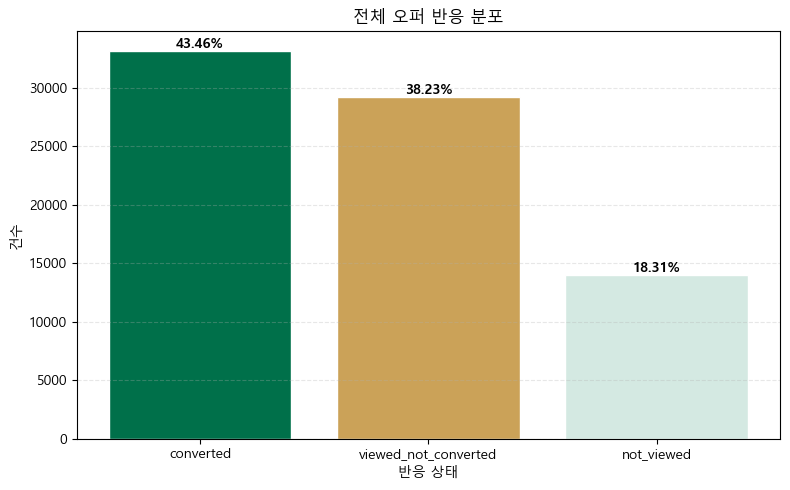

In [48]:
overall_funnel_breakdown = make_overall_funnel_breakdown(funnel_all)

print("=" * 80)
print("전체 전환 분포")
print("=" * 80)
display(overall_funnel_breakdown)

plot_overall_funnel_breakdown(overall_funnel_breakdown)

## 해석
전체 퍼널 분포를 보면 가장 큰 비중은 `전환 완료(converted)`지만,   이탈도 두 단계로 나뉘어 나타난다.
- `converted`: 43.46%
- `viewed_not_converted`: 38.23%
- `not_viewed`: 18.31%

즉, 오퍼를 아예 보지 않은 집단보다 오퍼는 봤지만 완료까지 이어지지 않은 집단이 더 크다.

이 말은 현재 퍼널의 핵심 개선 포인트가 단순 노출 확대만이 아니라 `열람 이후 완료 유도`에도 있다는 뜻이다.\
즉, 메시지를 열어보게 만드는 문제보다 열람 후 조건 충족까지 이어지지 않는 문제를 더 크게 봐야 한다.

In [49]:
# ============================================================
# 전체 퍼널 전환율 요약표 생성 함수
# 전체 퍼널 단계별 기준 건수, 성공 건수, 전환율을 계산
# received → viewed, viewed → completed, received → completed 3단계를 요약
# ============================================================
def make_overall_funnel_rate_summary(funnel_all, funnel_vc_main):

    # 전체 received / viewed / completed 건수 계산
    received_cnt = len(funnel_all)                       # 전체 오퍼 수신 건수
    viewed_cnt = int(funnel_all['converted_rv'].sum())  # received 이후 viewed 발생 건수
    completed_cnt = int(funnel_all['converted_rc'].sum())  # received 이후 completed 발생 건수

    # viewed → completed 분석용 기준 건수 계산
    viewed_base_cnt = len(funnel_vc_main)                           # 실제 viewed가 발생한 오퍼 건수
    completed_after_view_cnt = int(funnel_vc_main['converted_vc'].sum())  # viewed 이후 completed까지 이어진 건수


    # 퍼널 단계별 기준 건수 / 성공 건수 요약표 생성
    summary = pd.DataFrame({
        'funnel_step': [
            'received → viewed',
            'viewed → completed',
            'received → completed'
        ],
        'base_count': [
            received_cnt,        # received → viewed의 기준 건수
            viewed_base_cnt,     # viewed → completed의 기준 건수
            received_cnt         # received → completed의 기준 건수
        ],
        'success_count': [
            viewed_cnt,                  # received 이후 viewed 성공 건수
            completed_after_view_cnt,    # viewed 이후 completed 성공 건수
            completed_cnt                # received 이후 completed 성공 건수
        ]
    })

    # 퍼널 단계별 전환율 계산
    # 성공 건수 / 기준 건수 * 100
    summary['rate'] = summary['success_count'] / summary['base_count'] * 100

    return summary

In [50]:
# ============================================================
# 전체 퍼널 전환율 막대그래프 함수
# 퍼널 단계별 전환율을 막대그래프로 시각화
# received → viewed, viewed → completed, received → completed를 비교
# ============================================================
def plot_overall_funnel_rates(summary_df):
    # 퍼널 단계별 색상 지정
    color_map = {
        'received → viewed': '#4AA87A',         # 열람율: 연한 초록            
        'viewed → completed': '#CBA258',        # 완료율: 스타벅스 골드
        'received → completed': '#00704A'       # 전환율: 진한 스타벅스 그린
    }

    # 막대그래프 생성
    plt.figure(figsize=(8, 4.5))
    bars = plt.bar(
        summary_df['funnel_step'],                         # x축: 퍼널 단계
        summary_df['rate'],                                # y축: 전환율(%)
        color=[color_map[x] for x in summary_df['funnel_step']],
        edgecolor='white'
    )

    # 그래프 제목 및 축 라벨 설정
    plt.title('전체 퍼널 단계별 전환율')
    plt.xlabel('퍼널 단계')
    plt.ylabel('전환율 (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # 막대 위에 전환율 값 표시
    for bar, rate in zip(bars, summary_df['rate']):
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,   # x좌표: 막대의 가운데 위치
            h,                                   # y좌표: 막대 높이 위치
            f'{rate:.2f}%',                      # 표시할 텍스트: 소수점 둘째 자리까지 출력
            ha='center',                         # 텍스트를 x좌표 기준 가운데 정렬
            va='bottom',                         # 텍스트의 아래쪽이 y좌표에 맞도록 정렬
            fontsize=10                          # 글자 크기
        )

    # 레이아웃 정리 후 그래프 출력
    plt.tight_layout()
    plt.show()

전체 퍼널 전환율


,funnel_step,base_count,success_count,rate
0,received → viewed,76277,56567,74.159970
1,viewed → completed,46620,23496,50.398970
2,received → completed,76277,33152,43.462643


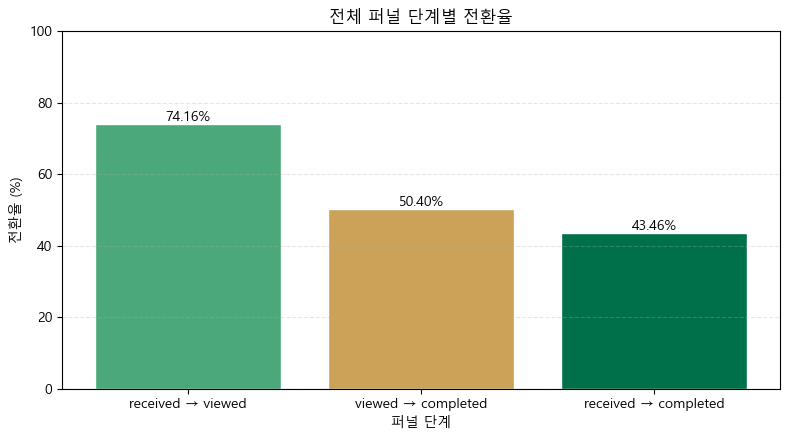

In [51]:
overall_funnel_rate_summary = make_overall_funnel_rate_summary(funnel_all, funnel_vc_main)

print("=" * 80)
print("전체 퍼널 전환율")
print("=" * 80)
display(overall_funnel_rate_summary)

plot_overall_funnel_rates(overall_funnel_rate_summary)

## 해석
전체 퍼널 단계별 전환율은 다음과 같다.
- `received → viewed`: 74.16%
- `viewed → completed`: 50.40%
- `received → completed`: 43.46%

첫 단계인 열람률은 비교적 높은 편이지만, 열람 이후 완료로 이어지는 비율은 절반 수준에 머문다.\
따라서 전체 전략 우선순위는 다음처럼 잡을 수 있다.

1. 이미 받은 오퍼를 실제로 보게 만드는 구조는 어느 정도 작동하고 있다.
2. 더 중요한 과제는 `본 고객을 어떻게 완료까지 밀어줄 것인가`이다.
3. 이 단계에서는 `discount` 유형, `mobile` 포함 채널 조합,\
그리고 중고숙성 고객 / 중상 소득층 같은 반응 좋은 집단을 함께 보는 전략이 유리하다.

---

# 종합 결론
고객은 동일한 프로모션에 똑같이 반응하지 않았고, 전환은 오퍼 유형 하나만으로 설명되기보다.\
고객의 가입 숙성도, 채널 조합, 세그먼트 특성, 열람 이후 단계의 설계가 함께 작동한 결과로 나타났다.

## 핵심 요약
- 가입기간은 `500 ~ 1000일` 구간에서 가장 강한 전환을 보였다.
- 채널은 `mobile` 포함, 그리고 다채널 조합일수록 전환율이 높았다.
- 오퍼 유형은 `bogo`가 열람에, `discount`가 완료에 더 강했다.
- 세그먼트별로는 중장년층, 중상 소득층, 일부 숙성 코호트에서 더 좋은 반응이 나타났다.
- 전체 퍼널에서는 `열람 후 미완료` 구간이 가장 큰 개선 지점이었다.

따라서 전체 고객에게 동일한 프로모션을 일괄 발송하기보다,\
가입기간이 어느 정도 누적된 고객과 반응 가능성이 높은 세그먼트를 중심으로\
`mobile`이 포함된 채널 조합을 활용하고,\
열람 단계에는 `bogo`, 완료 유도 단계에는 `discount`를 우선 배치하는 방향이 더 효과적인 전략이라고 볼 수 있다.